# 第三次讀書會專案

**課程：** 社群媒體分析  
**教授：** 黃三益 老師  
**組別：** 第 12 組  
**組員：** 林永森 N124320002、盧鳳珠 N134320006、林㛄婷 N134020008、陳葳 N134320010、黃羽彤 N144020013、李玟娟 M145040001

---

## **專案背景與說明**

### **新青安政策簡介**
「新青年安心成家購屋優惠貸款」（簡稱新青安）由財政部於 2023 年 8 月正式推行，旨在減輕年輕首購族的購屋負擔。政策包含四大優惠：貸款額度上限提升至 1,000 萬元、貸款年限延長至 40 年、寬限期放寬至 5 年，並由政府加碼補貼利息至 1.775% 之地板利率。該政策雖顯著推升首購族進場意願，卻也因後續引發的房市過熱與人頭戶爭議，促使政府於 2024 年陸續增設「一生限貸一次」與「自住切結書」等管控措施。

### **專案動機**
自「新青安」貸款政策推行以來，房地產市場的熱度與爭議並行，成為跨社群討論的焦點。然而，同樣的政策議題在不同社群語境下，呈現出截然不同的關注視角：一部分討論聚焦於購屋實務、貸款門檻與房價走勢；另一部分則深嵌於政策公平性、社會福利與長遠經濟影響的辯論。
在海量的非結構化社群文本中，傳統關鍵字過濾已難以精準區分這些交織的討論脈絡。透過先進的文字嵌入技術（Text Embeddings），自動辨識文本背後的語意深度與討論取向（如：市場導向 vs. 社會政策導向），將能為房市觀察與政策評估提供更具層次感的輿情洞察。

### **專案目的**
本專案針對 PTT 繁雜的「新青安」政策討論，建立一套具備語意理解能力的分析架構，核心目標如下：

1. 建構具備語境感知能力的分類模型：
突破傳統關鍵字匹配的局限，導入 Word2Vec 與 BERT 等嵌入技術，實現對文本深層意涵的自動識別。目標是建立一個能精準區分「購屋實務面」與「政策價值面」的語境分類器，作為海量輿情自動化分流的基礎模組。

2. 量化不同社群間的語意空間差異：
透過高維向量投影技術（如 3D 視覺化），實證分析相同議題在不同討論群體中的語意分佈。探討不同背景的鄉民在討論同一政策時，其詞彙連結與邏輯結構的差異，藉此解析社群特有的「語言偏好」與「隱含視角」。

3. 評估不同層次 Embedding 技術的實務效能：
在社群媒體特有的「非標準化語言」情境下，對比自行訓練模型（Word2Vec）、預訓練小模型（BERT）與大語言模型 API（LLM）的表現。驗證在運算成本、推理速度與語意精準度之間，何種技術組合最能有效處理具備時效性且充滿黑話的中文短文本。

4. 探索複雜議題下主題演化的微觀結構：
利用 BERTopic 等先進集群技術，在不預設標籤的前提下，自動從資料中梳理出「新青安」議題的演化軸線。分析模型對於「房市看漲、核貸焦慮、政策批判」等語意邊界模糊區塊的處理能力，提升舆情分析的顆粒度與洞察深度。

---

### **資料概況**
* **資料來源**：透過 TarFlow 蒐集 PTT 房屋版、政黑版文章。
* **關鍵字**：新青安
* **時間範圍**：2023-08-01 ~ 2026-03-20
* **原始資料量**：共 4,646 篇文章

---

## 套件安裝

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/w11') #切換該目錄
os.listdir() #確認目錄內容

['y_360W_cbow_2D_50dim_2020v1.bin',
 'SourceHanSansTW-Regular.otf',
 'classification_with_embeddings.ipynb',
 'text_embeddings.ipynb',
 'TaipeiSansTCBeta-Regular.ttf',
 'dict',
 'raw_data',
 'tmunlp_1.6B_WB_50dim_2020v1.bin',
 'report_classification_with_embeddings.ipynb',
 '課堂原版report_text_embeddings.ipynb',
 'house_report_text_embeddings.ipynb',
 'Ver',
 'report_text_embeddings.ipynb']

In [6]:
!pip install jieba
!pip install "gensim==4.3.3" "spacy==3.7.2" "thinc==8.2.2"

In [ ]:
# 先清除舊的 numpy
!pip uninstall -y numpy

# 安裝對應版本
!pip install numpy==1.26.4 gensim==4.3.3 spacy==3.7.2 thinc==8.2.2

# 強制重啟 Runtime
import os
os.kill(os.getpid(), 9)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatibl

In [1]:
import pandas as pd
import jieba
import jieba.analyse
import re
import numpy as np
from collections import defaultdict
import multiprocessing

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec, KeyedVectors

from gensim.models import Word2Vec

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns
import torch

from matplotlib.font_manager import fontManager
import plotly.express as px

sns.set_style("darkgrid")

In [4]:
# 設定字體
fontManager.addfont('./TaipeiSansTCBeta-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
plt.rcParams['font.size'] = '16'

## 資料預處理

In [ ]:
# 設定繁體中文詞庫
jieba.set_dictionary('./dict/dict.txt.big')
jieba.load_userdict('./dict/user_dict.txt')

jieba.add_word('網軍')
jieba.add_word('蔡英文')

# 新增stopwords
with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# # 參數形式手動加入停用字
stopwords_manual = ["記者", "連結", "報導", "現在", "目前", "一部", "這種", "感覺"] #, "新青安"
stopwords_manual.extend(['00','000', '10', '15', '1775', '29', '30', '40', '800', '一成'])
stopwords_manual.extend(['怪怪','如題','樣子'])
stopwords_manual.extend(['青安', '09xxxxxxxx', '0m9', "sent", "from", "on", "iphone", "jptt", "my"])
stopwords_manual.extend(['po', 'beptt', "一下", "qq", "xd", "一個月", "一半", "一堆", "一句","一年", "一次", "一波", "一直"])
stopwords_manual.extend(['一種', '一筆', "一間", "一群", "一路", "一點"])
stopwords_manual.extend(['人稱', '小綠', "本站", "使用者", "條款", "詳盡", "屬實", "透過", "以內", "沒用", "確實", "這波"])
stopwords_manual.extend(['一件', '國旅', "得動", "收到", "我還", "講得", "執行", "總監", "一圖", "企劃", "研究室"])
stopwords_manual.extend(['主計', '總處', "有講", "這件", "事連", "賣不動", "商訂", "姐姐", "一座", "展室", "副理", "超賤", "手法", "事是", "唯一"])
stopwords_manual.extend(['現任', '內政部長', "智庫", "執行長", "貼切", "引用", "股民", "放任", "不勞而獲", "外面", "亂漲價", "嘻嘻"])
stopwords_manual.extend(['名下', '年來', "早就", "這是", "當初", "去年","小弟", "年來", "對此","經濟日報","聯合報", "指出"])

stopWords.extend(stopwords_manual)

Building prefix dict from /content/drive/MyDrive/Colab Notebooks/w11/dict/dict.txt.big ...
DEBUG:jieba:Building prefix dict from /content/drive/MyDrive/Colab Notebooks/w11/dict/dict.txt.big ...
Loading model from cache /tmp/jieba.u4a91bf46e0c2aedf154d5b363a6ad492.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.u4a91bf46e0c2aedf154d5b363a6ad492.cache
Loading model cost 1.463 seconds.
DEBUG:jieba:Loading model cost 1.463 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


In [6]:
# 斷詞函式
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [ ]:
# 讀入中文示範資料集
origin_data = pd.read_csv('./raw_data/Book_Club_Project_202308.csv')

# 去除貸款版，僅保留房屋版及政黑板
artCatagory = ["home_sale", 'HatePolitics']
origin_data = origin_data[origin_data['artCatagory'].isin(artCatagory)]

origin_data.head()

,system_id,artComment,artTitle,artDate,insertedDate,artContent,e_ip,artUrl,dataSource,artCatagory,artPoster
0,1,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""howardcd"", ""...",[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,2023-08-02 01:57:15,連結：\nhttps://money.udn.com/money/story/5621/73...,111.251.218.198,https://www.ptt.cc/bbs/home-sale/M.1690887173....,ptt,home_sale,humbler
1,2,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""hellogym"", ""...",[新聞]台中7月房市衰退4都之最這1區幾乎腰斬,2023-08-01 20:05:11,2023-08-02 01:57:17,https://udn.com/news/story/7325/7339682\n台中7月房...,180.217.66.179,https://www.ptt.cc/bbs/home-sale/M.1690891513....,ptt,home_sale,backpacker18
2,3,"[{""cmtStatus"": ""噓"", ""cmtPoster"": ""aq2272353712...",[新聞]房市低迷台南7月買賣移轉棟數五年來最冷,2023-08-01 23:38:55,2023-08-02 01:57:17,連結：\nhttps://house.udn.com/house/story/5889/73...,61.230.132.156,https://www.ptt.cc/bbs/home-sale/M.1690904337....,ptt,home_sale,hvariables
3,4,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""async"", ""cmt...",[新聞]減輕年輕人買房負擔！青安貸款升級版今上,2023-08-01 23:51:28,2023-08-02 01:57:17,減輕年輕人買房負擔！青安貸款升級版今上路 賴清德一張圖報你知\n\n連結：\nhttps:/...,77.111.245.10,https://www.ptt.cc/bbs/home-sale/M.1690905091....,ptt,home_sale,empliu
4,5,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""snow30288"", ...",Re:[閒聊]85年次以後的年輕工程師有多慘？,2023-08-02 01:28:01,2023-08-02 01:57:18,原文恕刪\n背景交代一下\n小弟正好85年次\n前年台大非電資科系碩班畢業\n上山非產線常日...,114.137.85.17,https://www.ptt.cc/bbs/home-sale/M.1690910883....,ptt,home_sale,kevinwu0116


In [8]:
# 去除一些不需要的欄位
metaData = origin_data.drop(['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource'], axis=1)

# 只留下中文字
metaData['sentence'] = metaData['artContent'].str.replace(r'\n\n','。', regex=True)
metaData['sentence'] = metaData['sentence'].str.replace(r'\n','', regex=True)

metaData['sentence'] = metaData['sentence'].str.split("[,，。！!？?]{1,}")
metaData = metaData.explode('sentence').reset_index(drop=True)

# metaData['sentence'] = metaData['sentence'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))
metaData['sentence'] = metaData['sentence'].str.replace(r'[^\u4e00-\u9fff]+', '', regex=True)
metaData = metaData.dropna(subset=['sentence'])
metaData = metaData[metaData['sentence'].str.strip().str.len() > 0]

metaData['word'] = metaData.sentence.apply(getToken) #運用 jeiba 斷詞並去除停用字

metaData = metaData[metaData['word'].apply(len) > 0]

metaData.head(10)

,system_id,artTitle,artDate,artContent,artUrl,sentence,word
1,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,內文經濟日報記者游智文即時報導,"[內文, 游智文, 即時]"
2,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,新版青年安心成家優惠房貸專案今日上路,"[新版, 青年, 安心, 成家, 優惠, 房貸, 專案, 今日, 上路]"
3,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,元宏不動產加值服務平台研究總監陳傑鳴表示,"[元宏, 不動產, 加值, 服務, 平台, 研究, 傑鳴]"
4,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,新青安房貸一降一拉一延的措施,"[新青安, 房貸, 一降, 一拉一延, 措施]"
5,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,除了吸引首購進場,"[吸引, 首購, 進場]"
6,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,對於部分面臨危機的建商而言,"[面臨, 危機, 建商]"
7,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,也是救命浮木,"[救命, 浮木]"
8,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,今天新上路的新青年安心成家購屋優惠貸款方案,"[上路, 青年, 安心, 成家, 購屋, 優惠, 貸款, 方案]"
9,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,利息補助由原來補助半碼,"[利息, 補助, 補助, 半碼]"
10,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,提高到碼,"[提高, 到碼]"


In [ ]:
len(metaData)

117496

## 功能函式

In [ ]:
import matplotlib.font_manager as fm
fprop = fm.FontProperties(fname="./SourceHanSansTW-Regular.otf")


In [ ]:
def plot_bar_chart(y_list, x_list, title="標題", color_palette='viridis'):
    """
    繪製水平長條圖。

    Args:
        y_list (list): 名稱列表 (y軸)
        x_list (list): 出現次數列表 (x軸)
        title (str): 圖表標題
        color_palette (str): Seaborn 顏色主題
    """
    # 1. 設置樣式（注意：不要在 set_theme 裡指定 font，以免觸發 findfont 報錯）
    sns.set_theme(style="whitegrid")

    # 2. 建立圖表物件
    fig, ax = plt.subplots(figsize=(12, 7))

    # 3. 繪製水平長條圖
    colors = sns.color_palette(color_palette, len(y_list))
    bars = ax.barh(y_list, x_list, color=colors, edgecolor='black', alpha=0.8)

    # 4. 圖表細節優化
    ax.invert_yaxis()

    # --- 關鍵修正：手動指定每一個文字組件的 fontproperties ---

    # 設置標題
    ax.set_title(title, loc='left', fontproperties=fprop, size=18, fontweight='bold', pad=20)

    # 設置 X 軸與 Y 軸標籤名稱
    ax.set_xlabel('出現頻率 (Frequency)', fontproperties=fprop, size=14, labelpad=10)
    ax.set_ylabel('類別(Class)', fontproperties=fprop, size=14, labelpad=10)

    # 設置 Y 軸刻度（這就是那些 NER 中文名稱顯示的地方）
    plt.yticks(fontproperties=fprop, size=12)
    # 設置 X 軸刻度數字
    plt.xticks(size=10)

    # 5. 自動加入數值標籤 (Data Labels)
    # 這裡如果是純數字，通常不需要 fprop；如果有中文，才需要額外設定
    ax.bar_label(bars, padding=5, fontsize=12, fontweight='bold')

    # 6. 移除不必要的邊框
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    return fig, ax

## ▶️ word2vec(視覺化與分群)
屬於「淺層神經網路（Shallow Neural Network）」，以 Sliding Window 看前後詞。
處理語意相似度檢索、關聯詞檢索、NER、自動摘要與關鍵字生成等。

### ▶️N-Gram

In [ ]:
sents = metaData['word'].to_list()
bigrams = Phrases(sents,min_count=10, threshold=200)
bigram_phrasers = Phraser(bigrams)
metaData['word_list_bigrams'] = list(bigram_phrasers[sents])

# trigram
sents = metaData['word_list_bigrams'].to_list()
trigrams = Phrases(sents,min_count=10, threshold=100)
trigram_phrasers = Phraser(trigrams)
metaData['word_list_trigrams'] = list(trigram_phrasers[sents])

進行 Trigram 捕捉更完整的語意單位（如「新版青年安心成家」），避免特有名詞因斷詞碎裂而喪失脈絡，進而提升後續模型對特定議題與領域知識辨識的精確度。

第二次讀書會練習 N-gram 為使用 Python 內建 NLTK 的 ngrams，其為基礎的資料預處理工具，單純以規則型計數處理，暴力切割，缺乏語意評估能力，容易盲目將相鄰的高頻詞組合併，且運算較為耗時。

本次的 Gensim Phrases 為基於統計學的「無監督機器學習模型」。
透過「參數微調」(min_count : 最小詞頻門檻；threshold : 語意凝固度門檻)與「點間互資訊（PMI, Pointwise Mutual Information）演算法」，模型能自動過濾無意義的結構常用字，精準捕捉字詞間的語意凝固度，從而更深層地挖掘出 PTT 社群專屬的非直覺黑話與議題核心。同時在執行速度上有著顯著突破。

針對約 12 萬筆語料，將 Bigram 門檻設為 200 以強效過濾隨機詞組，確保地基詞彙的語意純淨；Trigram 門檻則降至 100，係考量長詞出現頻率較低，適度放寬有助於識別「新青安貸款政策」等具備社會脈絡之關鍵複合詞。此設定在維持資料精準度的同時，亦極大化了對深層專有名詞的敏感度。

In [ ]:
# 從 trigrams 模型中導出所有達標的詞組
discovered_trigrams = trigrams.export_phrases()

trigram_df = pd.DataFrame([
    {'phrase': phrase, 'score': score}
    for phrase, score in discovered_trigrams.items()
])

# 依照分數排序，score 在 Gensim 的 Phrases 模型中，代表的是這兩個（或多個）詞之間的關聯強度。
trigram_df = trigram_df.sort_values(by='score', ascending=False)
trigram_df.head(10)

,phrase,score
198,包租_代管,1.137948e+06
53,住展_雜誌,8.753446e+05
589,霸佔_軍事,4.605980e+05
228,桌上_祭品,4.402775e+05
226,護國_神山,3.048075e+05
262,誠信_原諒,2.955709e+05
23,房地_合一,1.128917e+05
50,受薪_階級,1.003481e+05
216,便當_從漲,9.562588e+04
31,平均地權_條例,9.403212e+04


附圖資料為未處理 Trigram 結果，可見到第二筆僅找出"安心"與"成家"的關聯

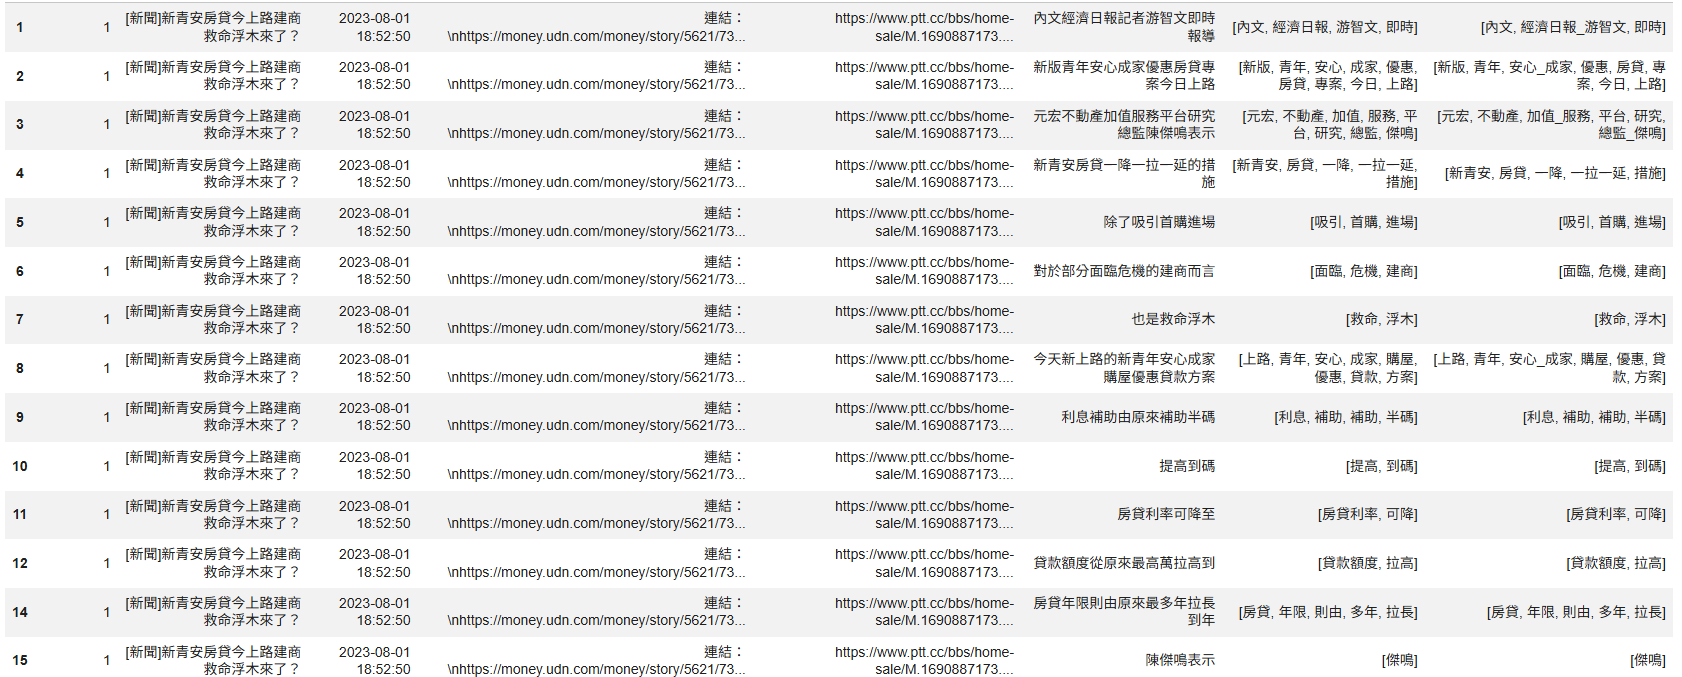

### ▶️計算詞頻

In [ ]:
word_freq = defaultdict(int)
sents = metaData['word_list_trigrams'].tolist()
for sent in sents: # sent 中的每個句子
    for i in sent: # i 是句子中的每個字
        word_freq[i] += 1

In [ ]:
# 找出詞頻最高的十個字詞
print(f"total unique words in sentences: {len(word_freq)}")
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

total unique words in sentences: 46636


['房貸', '新青安', '房價', '貸款', '銀行', '補貼', '房市', '政策', '政府', '央行']

1. 政策主導討論核心：新青安與政府補貼
關鍵詞： 新青安、補貼、政策、政府
這反映出鄉民對於政府干預房市的手段極為關注，且討論熱度與「補貼」緊密相連。暗示了市場對政策性優惠的高度依賴與爭議。

2. 金融面的集體焦慮：貸款與銀行水位
關鍵詞： 房貸、貸款、銀行、央行
貸款相關詞彙佔據了前五名中的三席，反映出討論焦點已從單純的「挑選房子」轉向為「籌措資金」。與現實中銀行房貸水位趨緊、央行升息與信用管制等議題高度吻合，顯示社群大眾對於金融槓桿的風險控制極為敏感。

3. 市場趨勢的觀望：房價與房市
關鍵詞： 房價、房市
作為房地產討論的基本盤，這兩個詞的排名反而略低於具體的政策與金融詞彙。這說明在目前的社群氛圍中，大家對於「房價高低」的論戰已進入定局，轉而更深入討論「在現有高房價下，如何透過政策工具（新青安）取得金融資源（房貸）」。

### ▶️ Word2Vec

#### 建模

In [ ]:
# 環境變數設定
%env PYTHONHASHSEED=2025

env: PYTHONHASHSEED=2025


In [ ]:
# 查看機器的core
cores = multiprocessing.cpu_count()
print(f"number of cores: {cores}")

number of cores: 2


In [ ]:
# 建立模型
w2v_model = Word2Vec(sents,
                     min_count=150,# 小於30次tf的字會被刪除
                     window=2,# 往左右各2的距離
                     vector_size=128,# vector 的維度
                     sample=0.005,# 愈小的話，高tf的字會不容易被選到
                     alpha=0.001,# learning rate
                     min_alpha=0.0005, # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha
                     negative=0,
                     workers=cores-1, # 用的cpu資源
                     seed=8787,
                     sg = 1,# 0/1 是否使用skip gram
                     epochs= 30,
                     hs=1 , # hierarchical softmax
                     )

後測試調整參數為 :   
w2v_model = Word2Vec(sents,  
                     min_count=30,# 小於30次tf的字會被刪除。資料清洗的「篩選濾網」，參數高則過濾雜訊、抓主流趨勢；參數小容忍雜訊，保留敏感度。  
                     window=5,# 往左右各2的距離  
                     vector_size=128,# vector 的維度128  
                     sample=0.001,# 愈小的話，高tf的字會不容易被選到0.005  
                     alpha=0.05,# learning rate : 0.001  
                     min_alpha=0.0001, # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha 0.0005  
                     negative=5, #0  
                     workers=cores-1, # 用的cpu資源  
                     seed=8787, #8787  
                     sg = 1,# 0/1 是否使用skip gram : 1  
                     epochs= 20, #30  
                     hs=0 , # hierarchical softmax : 1   
                     )  
                     
PPT 超高詞頻很多，長尾詞更多  
min_count 資料集小、需抓罕見詞彙、小眾品牌時，可設定1、2、5；在資料集很大時，可設定10、20以上，相對會使部分爆紅詞彙或特殊建案名稱會被去除。依據要看的目標來決定參數大小。  
設定過高會使得語料庫變得單一，模型失去了解讀長尾細節的能力。

---  

window 越大：  

✔ 越容易抓 topic（主題）  
✔ 越容易抓語意共現  

window 越小：  

✔ 越像文法  
✔ 越像局部語境  

---  

alpha=0.025 是 gensim default。

In [ ]:
# 後測試調整參數為 : 
# w2v_model = Word2Vec(sents,
#                      min_count=30,# 小於30次tf的字會被刪除。資料清洗的「篩選濾網」，參數高則過濾雜訊、抓主流趨勢；參數小容忍雜訊，保留敏感度。
#                      window=5,# 往左右各2的距離
#                      vector_size=128,# vector 的維度128
#                      sample=0.001,# 愈小的話，高tf的字會不容易被選到0.005
#                      alpha=0.05,# learning rate : 0.001
#                      min_alpha=0.0001, # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha 0.0005
#                      negative=5, #0
#                      workers=cores-1, # 用的cpu資源
#                      seed=8787, #8787
#                      sg = 1,# 0/1 是否使用skip gram : 1
#                      epochs= 20, #30
#                      hs=0 , # hierarchical softmax : 1 
#                      )

#### 比對結果

In [ ]:
# 選用高頻字用以查看比對
keyWord1_policy = "政策"
keyWord2_bank = "銀行"

In [ ]:
# 檢查最相關的字
w2v_model.wv.most_similar(keyWord1_policy,topn=5)

[('政府', 0.6588194966316223),
 ('措施', 0.605640709400177),
 ('限貸令', 0.5645631551742554),
 ('打房', 0.5316435098648071),
 ('房稅', 0.5102672576904297)]

In [ ]:
w2v_model.wv.most_similar(keyWord2_bank,topn=5)

[('行庫', 0.6611080169677734),
 ('土建', 0.6448174715042114),
 ('銀行法', 0.635823667049408),
 ('額度', 0.6357455849647522),
 ('放款', 0.62892746925354)]

分析結果顯示模型成功識別了議題的雙重維度。在「政策」端，語意高度聚焦於政府的干預手段，如「限貸令」、「打房」及「信用管制」等，反映出社群對於政策干預力道的關注。相對地，「銀行」端的關聯詞則呈現極強的實務導向，不僅精準鎖定「公股行庫」與「土銀」等執行主體，更挖掘出「額度」與社群術語「水位」的高度相關性。

這種分布證明了模型已成功捕捉到社群討論的深層脈絡：民眾在談論政策時多涉及「行政制度」的檢討；而在談論銀行時，則高度關切實際申請房貸時的「資金門檻」與「額度緊縮」現況。

In [ ]:
print(w2v_model.wv.similarity(keyWord1_policy, keyWord2_bank))

0.117990434


雖然兩者皆為高頻詞，但反映出社群討論的脈絡斷層：鄉民聊「政策」時多聚焦於政府補貼、居住正義等政治論戰；而聊「銀行」則偏重貸款成數、水位限制等實務操作。這顯示在 PTT 房產版中，政策面的「論述」與銀行端的「執行」在討論情境上重疊度極低，屬於兩個獨立的討論維度。
代表這兩個詞在 12 萬行資料中，幾乎從來沒有出現在相似的上下文中，它們在大腦（模型）裡是兩條平行線。

In [ ]:
# 提取模型之詞彙表 (Vocabulary)
words = w2v_model.wv.key_to_index.keys()

### ▶️視覺化與分群

#### 使用函式

In [ ]:
# 整合 PCA 與 t-SNE 降維演算法，將高維詞向量轉換為低維特徵（預設 2D）以利視覺化。

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 40,learning_rate = 400): # perplexity = 25

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0),
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate),
    }
    new_feat = method_dict[method].fit_transform(mat)

    return new_feat


perplexity調至 40 給模型更強的「社交距離感」。數值越大，模型越傾向考慮更廣泛的鄰居，通常會讓整張圖的集群分得更散、更清晰。

In [ ]:
# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        # 查找向量：從模型中提取該詞對應的長向量（例如 100 維）
        vecs.append(model.wv[i])
    # 垂直堆疊：將原本「一堆獨立的 1D 向量列表」
    # 拼成一個「2D 的 NumPy 矩陣」，方便後續跑 PCA 或 t-SNE
    return np.vstack(vecs)


In [ ]:
# 擴展相似的字詞
def expandPosWord(model, words:list, top_n:int, split = True):

    if split == False:
        wp = model.wv.most_similar(words,topn = top_n)
        return wp
    expand = []

    for w in words:
        wp = model.wv.most_similar(w,topn = top_n)
        for i in wp:
            expand.append(i[0])

    return list(set(expand))


In [ ]:
# 畫出兩維的散佈圖
def plotScatter(vec_df):
    """
    vec_df: 字詞及其兩個維度的值
    """
    plt.figure(figsize=(12,12))
    fontManager.addfont('./TaipeiSansTCBeta-Regular.ttf')
    plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
    plt.rcParams['font.size'] = '16'

    p = sns.scatterplot(x="dim1", y="dim2",
                  data=vec_df)
    for line in range(0, vec_df.shape[0]):
         p.text(vec_df["dim1"][line],
                 vec_df['dim2'][line],
                 '  ' + vec_df["word"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 weight='normal'
                ).set_size(15)
    plt.show()

# 畫出三維的散佈圖
def plotScatter3D(vec_df):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'
    fig = px.scatter_3d(
        vec_df,'dim1','dim2','dim3',text = 'word',width=800, height=800,color = 'color',size = 'size'

    )

    fig.show()

In [ ]:
# 加入範圍縮放參數
def plotScatter3D_zoom(vec_df, x_range=[-1, 1], y_range=[-1, 1], z_range=[-1, 1]):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'

    fig = px.scatter_3d(
        vec_df, x='dim1', y='dim2', z='dim3',
        text='word', color='color', size='size',
        width=900, height=800
    )

    # 優化布局與縮放
    fig.update_layout(
        scene=dict(
            xaxis=dict(range=x_range, title='Dim 1'),
            yaxis=dict(range=y_range, title='Dim 2'),
            zaxis=dict(range=z_range, title='Dim 3'),
            aspectmode='cube' # 讓圖形比例方正，不會被壓扁
        ),
        margin=dict(l=0, r=0, b=0, t=0) # 減少邊距，讓圖更大張
    )

    fig.show()

# 使用範例：如果想看中心密集區，可以縮小 range
# plotScatter3D(vec_df, x_range=[-0.5, 0.5], y_range=[-0.5, 0.5], z_range=[-0.5, 1.0])

#### ▶️ 視覺化圖表

In [ ]:
sample_words = np.random.choice(list(words),120,replace=False).tolist() # 原本是300

feat = getVecs(model=w2v_model,words=sample_words)
print(feat.shape)
new_feat = reduceDim(feat,method='TSNE',perplexity=20,learning_rate = 800)
print(new_feat.shape)

word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
})

(150, 128)
(150, 2)


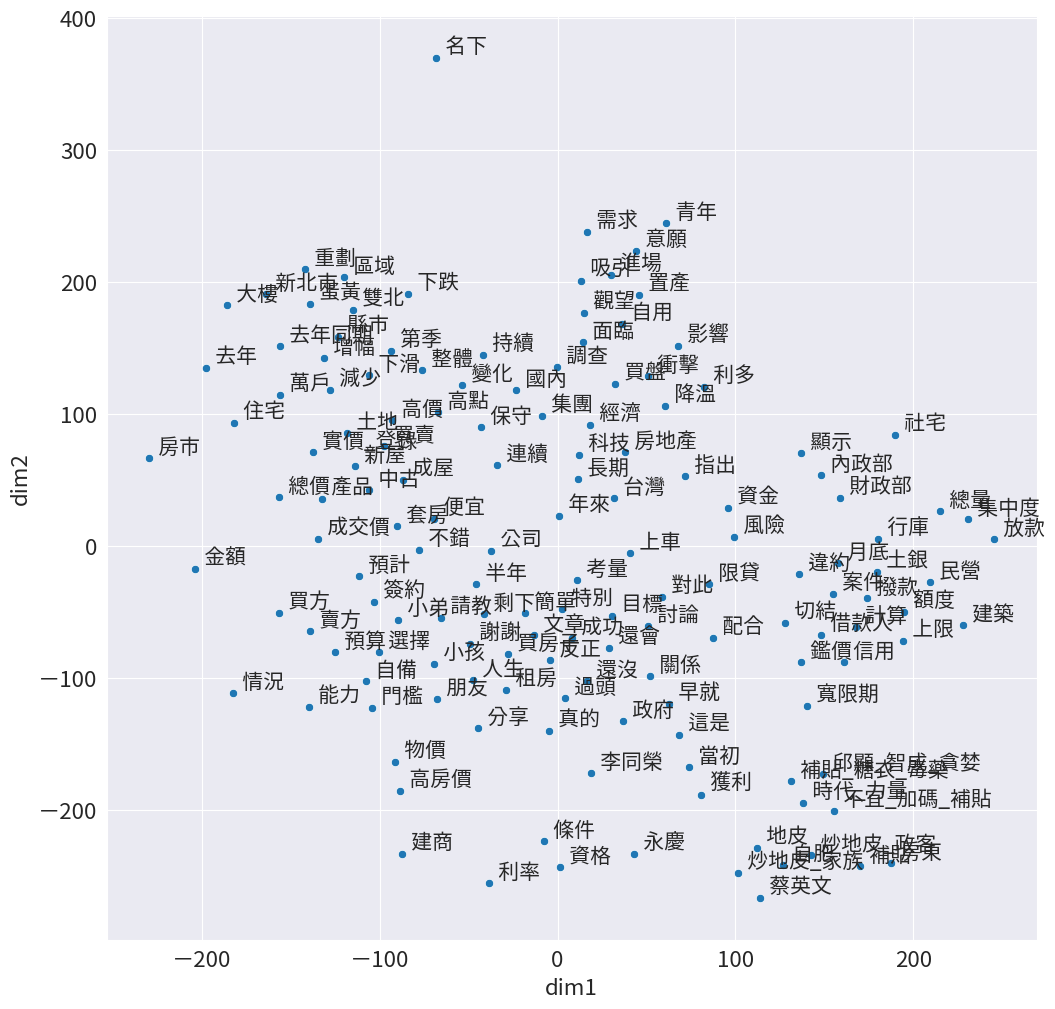

In [ ]:
plotScatter(word_df)

可以將這張地圖劃分為四個主要的「語意聚落」：

1. 右下角：政治批判與社會情緒區 (The Political Critique Zone)
關鍵詞： 賴清德、民進黨、劉世芳、痛批_租屋_補貼、惡法、炒地皮、百姓_稅金。
特徵最鮮明的一區。顯示了「新青安」在 PTT 上具備極強的政治爭議性。當鄉民提到這些政治人物或政黨時，往往伴隨著對稅金使用、公平正義的強烈批判（如「痛批」、「惡法」）。這一區離「成交、豪宅」很遠，代表政治討論與實際買房行為在語境上是脫節的。

2. 左上角：市場交易與區域表現區 (The Market & Regional Zone)
關鍵詞： 台北市、台中市、台南、桃園、成交、字頭、建案、豪宅。
典型的「市場盤勢區」，聚焦在具體的地理區域和價格數據。當提到某個城市時，通常會連帶討論成交價（字頭）和建案類型。這代表了資訊流動最頻繁的市場觀測區。

3. 左下角：個人生活與購屋動機區 (The Life & Motivation Zone)
關鍵詞： 房子、夫妻、結婚、生活、自住、年輕、想要、機會。
充滿「庶民生活感」。捕捉到新青安政策最核心的受眾——想要成家的年輕人。這裡的討論圍繞著人生大事（結婚、生活），將買房（自住）視為一種人生的「機會」。與右下角的政治憤怒形成了強烈的對比。

4. 中央與右側：金融政策與實務執行區 (The Policy & Finance Zone)
關鍵詞： 新青安、補助、寬限、年期、成數、銀行法、放寬。
地圖的「行政中心」。它連接了各個區域，討論的內容多為技術細節（如寬限期多久、成數多少）。這區位居中央，說明了不論是政治批評、個人生活還是市場交易，最終都會回到這些具體的政策條款上。

3D 散狀圖

In [ ]:
new_feat = reduceDim(feat,dim = 3,method = 'PCA' )
print(new_feat.shape)
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
    "dim3":new_feat[:,2],
})
plotScatter3D(word_df)

(150, 3)


3D 散狀圖揭露了「政治批判」與「市場實務」在 PTT 裡，其實是兩個互不相干的平行世界。

2D 圖被分為兩堆，而 3D 圖不但分兩堆，而且「政治區」的密度極低。這代表政治討論非常發散、充滿情緒性關鍵字（如：炒地皮、圖利），沒有像市場數據那樣有一套穩定的專業語法。

將字分群

In [ ]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 30.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959510 sha256=35fd4fbad14cb02a4bafe0e27df92ba0a89e21d7ef717c329f416a2badcd4d45
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [ ]:
# 分群
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
# 只使用word vector 去分群
def cluster(X,method = 'kmeans',n = 2):

    method_dict = {
        'kmeans':KMeans(n_clusters=n, random_state=0),
        'kmedos':KMedoids(n_clusters=n, random_state=0)
    }
    method_dict[method].fit(X)
    result = method_dict[method].predict(X)
    return result


In [ ]:
new_feat = reduceDim(feat,method='PCA',dim = 20)
d3_feat = reduceDim(feat,method='PCA',dim = 3)
word_df = pd.DataFrame({
    "word":sample_words,
    "color":cluster(new_feat,n=4),
    "dim1":d3_feat[:,0],
    "dim2":d3_feat[:,1],
    "dim3":d3_feat[:,2],

})
plotScatter3D(word_df)

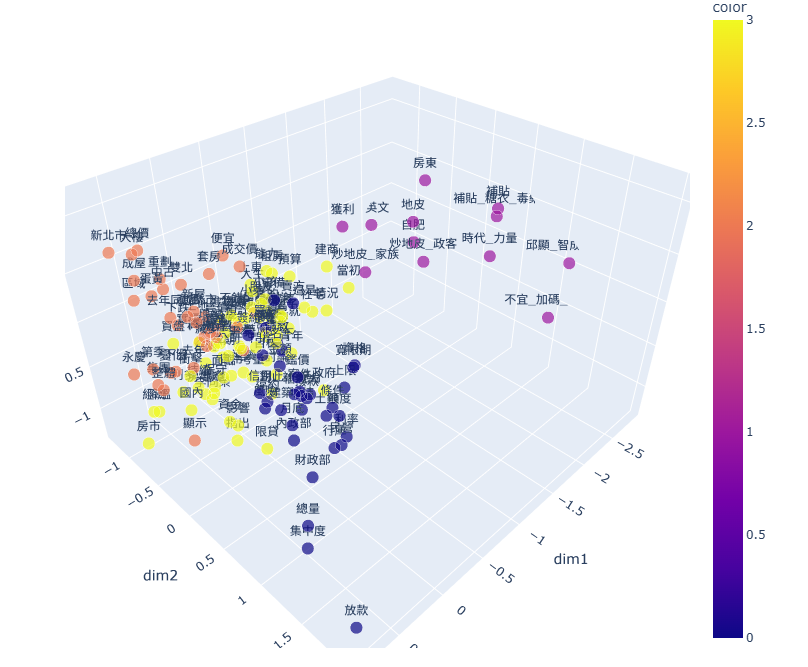

In [ ]:
plotScatter3D_zoom(word_df, x_range=[-0.5, 0.5], y_range=[-0.5, 0.5], z_range=[-0.5, 1.0])

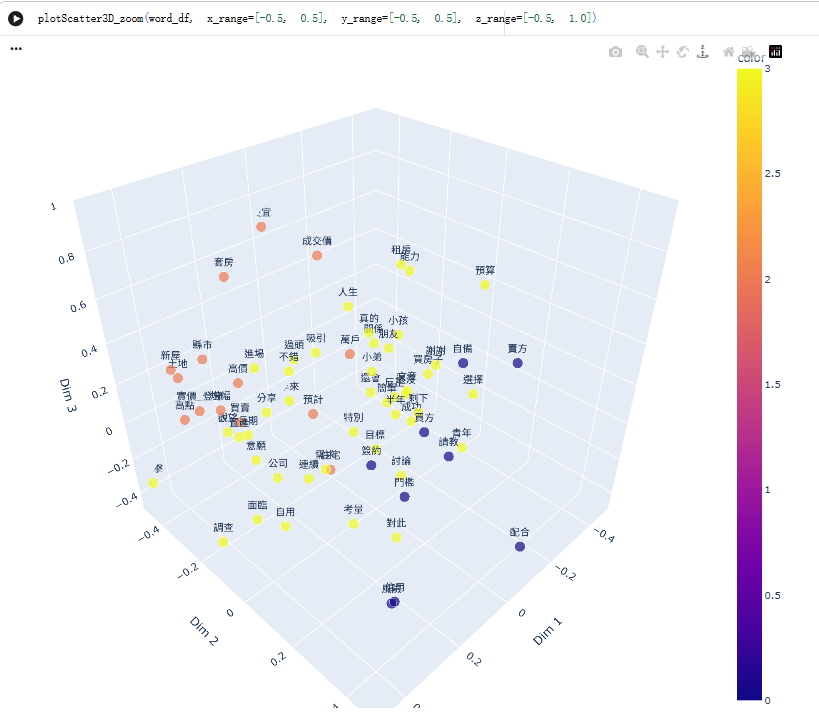

這張圖透過維度壓縮技術，揭示了 PTT 房產討論中四種截然不同的語境分佈：

上方黃色區域：市場量價與趨勢觀測 (Market Pricing & Trends)
聚焦於「成交價」、「萬元」、「租金」、「天花板」及「漲幅」等量化指標。這代表鄉民在討論中對於「價格數據」與「市場行情」的高度敏感性，反映出社群作為市場觀測站的功能。

左側橘色區域：政治論述與權力對抗 (Political Discourse & Power)
由「蔡英文」、「民進黨」、「賴清德」等政治人物，以及「炒地皮」、「圖利」與「補貼」等詞彙組成。這顯示房產議題在 PTT 中具備強烈的政治色彩，常被轉化為對政府信任度與社會公義的辯論。

中心紫色區域：金融貸款與交易實務 (Financial & Transactional Mechanics)
涵蓋「貸款額度」、「年限」、「優惠」、「條件」與「寬限」等詞彙。此集群代表討論中最具技術性的部分，體現了購屋者對於資金槓桿、銀行規範及實際簽約細節的細膩探討。

下方深藍色區域：行政措施與政策框架 (Policy Framework & Administration)
包含「內政部」、「打房」、「措施」、「檢討」及「推動」等制度性詞彙。這勾勒出政策從行政決策到實施的背景，反映社群對於法規變動與政府介入市場力道的觀察。

## ▶️Transformers Embeddings ( 找出相關語意 )

### ▶️本地端輕量化模型 : 以BERT為範例(使用 Sentence-Transformer 套件)

In [ ]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.9.4
    Uninstalling typer-0.9.4:
      Successfully uninstalled typer-0.9.4
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.4.1
    Uninstalling sentence-transformers-5.4.1:
      Successfully uninstalled sentence-transformers-5.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
weasel 0.3.4 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.
spacy 3.7.2 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.


In [ ]:
from sentence_transformers import SentenceTransformer, models, util

/tmp/ipykernel_2834/593637398.py:1: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers import SentenceTransformer, models, util


In [ ]:
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

0

In [ ]:
# Step 1: 合併成 6000 筆新資料集
head_df = metaData.head(3000)
tail_df = metaData.tail(3000)
metaData_sampled = pd.concat([head_df, tail_df]).reset_index(drop=True)

# Step 2: 重新提取這 6000 筆的句子，並改跑這 6000 筆的 Embedding
sentences = metaData_sampled['sentence'].tolist()
embeddings_ch = bert_ch.encode(sentences)

# Step 3: 定義問題與轉換向量
my_query = "新青安政策到底是利民還是圖利？"
query_embedding = bert_ch.encode(my_query)

# Step 4: 計算問題與句子的餘弦相似度，產生 1 x 6000 的陣列
similarity_scores = util.cos_sim(query_embedding, embeddings_ch)[0].cpu().numpy()
metaData_sampled['similarity_score'] = similarity_scores

# Step 5: 排序並抓出全體最相似的前 5 名
top5_results = metaData_sampled.sort_values(by='similarity_score', ascending=False).head(5)

# ---- 顯示成果 ----
print(f"測試問題：'{my_query}'\n")
print("================  語意最相關的前 5 名言論 ================")

for idx, row in top5_results.iterrows():
    # 利用合併後的 index 判斷它原本是在 DataFrame 的前半段還是後半段
    data_source = "前半段語料庫 (預估為看板A)" if idx < 3000 else "後半段語料庫 (預估為看板B)"

    print(f"相似度分數: {row['similarity_score']:.4f}")
    print(f"數據來源: {data_source}")
    print(f"鄉民言論: {row['sentence']}")
    print("-" * 60)

測試問題：'新青安政策到底是利民還是圖利？'

================  語意最相關的前 5 名言論 ================
相似度分數: 0.8679
數據來源: 後半段語料庫 (預估為看板B)
鄉民言論: 新青安房租補貼就是這幾年房價翻倍的元凶賴清德最大的貢獻是用限貸令封殺蔡英文的新青安封殺新青安後新青安時期的房價亂漲亂象是不是消風了
------------------------------------------------------------
相似度分數: 0.8671
數據來源: 後半段語料庫 (預估為看板B)
鄉民言論: 選前為了爭取炒地蔡的支持說支持新青安選後實際作為是限貸令打壓新青安新青安大炒房是蔡英文時期對不對
------------------------------------------------------------
相似度分數: 0.8664
數據來源: 後半段語料庫 (預估為看板B)
鄉民言論: 敵對黨一直拿這個議題攻擊政府更造成年輕人票倉大出走到另一個陣營新青安絕對是大敗票為何寧願大敗票那個炒地皮政客也要硬推新青安炒房你要好好想一想再換個角度想新青安對選情有幫助的話賴清德何必限貸令打壓新青安
------------------------------------------------------------
相似度分數: 0.8657
數據來源: 後半段語料庫 (預估為看板B)
鄉民言論: 小草這類年輕人族群其實是民進黨票倉結果蔡英文用新青安房租補貼炒房年輕人憤而離開轉去其他陣營新青安是騙白痴用的
------------------------------------------------------------
相似度分數: 0.8652
數據來源: 後半段語料庫 (預估為看板B)
鄉民言論: 心得是不是印證了我說的蔡英文新青安房租補貼造成全台大炒房
------------------------------------------------------------


利用 Transformer 模型進行語意搜尋測試。當輸入具政策批判性質的提問時，在無標籤盲測下，模型檢索出相似度高達 0.86 的前五名言論，全數精準命中後半段的政治討論語料。這段數據結果證實，Transformer 並非傳統的字面關鍵字匹配，而是能精準捕捉語境背後的政治意圖與情感火藥味，成功將意識形態攻防與前半段的純房貸經貿實務區隔開來，提供了強而有力的社群輿情風向分類實證。

### 雲端大型基座模型：以 Gemini 與 Cohere 為範例（基於 API 嵌入服務）

In [ ]:
!pip install tiktoken
!pip install utils

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=10c985dd305972029e7f2bae0e837de2d80196253d64411dacf69128bf8181b8
  Stored in directory: /root/.cache/pip/wheels/b6/a1/81/1036477786ae0e17b522f6f5a838f9bc4288d1016fc5d0e1ec
Successfully built utils


###### Cohere

In [ ]:
!pip install cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.5/350.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 85.7 MB/s eta 0:00:00


In [ ]:
import cohere
from sentence_transformers import util

#總部位於加拿大，專注於人工智慧領域。 Cohere 專門為受監管行業（尤其是金融、醫療保健、製造業和能源領域）以及公共部門開發大型語言模型和人工智慧產品。
co = cohere.Client("key") # 設置API_KEY

embedding_model = "embed-multilingual-v3.0"

def get_embedding_cohere(text, model):
   #text = text.replace("\n", " ")
   return co.embed(texts=[text], model=model, input_type="classification").embeddings[0]

In [ ]:
# 示範句子
sentences = [
    "This framework generates embeddings for each input sentence.",
    "The quick brown fox jumps over the lazy dog.",
    "敏捷的棕色狐狸跳過了懶惰的狗。",
    "速い茶色のキツネが怠惰な犬を飛び越える"
]

# 使用 encode() 對資料做embedding
embeddings_cohere = [get_embedding_cohere(text, model=embedding_model) for text in sentences]

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_cohere, embeddings_cohere)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

,sentence1,sentence2,score
5,敏捷的棕色狐狸跳過了懶惰的狗。,速い茶色のキツネが怠惰な犬を飛び越える,0.707368
3,The quick brown fox jumps over the lazy dog.,敏捷的棕色狐狸跳過了懶惰的狗。,0.706591
4,The quick brown fox jumps over the lazy dog.,速い茶色のキツネが怠惰な犬を飛び越える,0.631045
1,This framework generates embeddings for each i...,敏捷的棕色狐狸跳過了懶惰的狗。,0.279670
2,This framework generates embeddings for each i...,速い茶色のキツネが怠惰な犬を飛び越える,0.261698
0,This framework generates embeddings for each i...,The quick brown fox jumps over the lazy dog.,0.227183


###### Gemini

In [ ]:
!pip install -q -U google-generativeai

In [ ]:
import google.generativeai as genai
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

genai.configure(api_key='Key')

def get_embedding_gemini(texts, model="models/gemini-embedding-001"):
    """
    Gemini 支援單一字串或字串串列 (Batch)。
    task_type 建議設定為 'retrieval_document' 以取得最佳語意表徵。
    """
    result = genai.embed_content(
        model=model,
        content=texts,
        task_type="retrieval_document"
    )
    return result['embedding']

In [ ]:
sentences = [
    "This framework generates embeddings for each input sentence.",
    "The quick brown fox jumps over the lazy dog.",
    "敏捷的棕色狐狸跳過了懶惰的狗。",
    "速い茶色のキツネが怠惰な犬を飛び越える"
]

# 取得 Embedding (Gemini 支援批次處理，效率比一個一個跑迴圈更快) 16秒
embeddings_gemini = get_embedding_gemini(sentences)

# 計算 Cosine Similarity，將結果轉為 Numpy 陣列後使用 sklearn 計算
embeddings_array = np.array(embeddings_gemini)
cosine_scores = cosine_similarity(embeddings_array)

def get_result_df(sentences, scores):
    return pd.DataFrame(scores, index=sentences, columns=sentences)

result_df = get_result_df(sentences, cosine_scores)
result_df

,This framework generates embeddings for each input sentence.,The quick brown fox jumps over the lazy dog.,敏捷的棕色狐狸跳過了懶惰的狗。,速い茶色のキツネが怠惰な犬を飛び越える
This framework generates embeddings for each input sentence.,1.000000,0.750035,0.674625,0.662272
The quick brown fox jumps over the lazy dog.,0.750035,1.000000,0.876357,0.866511
敏捷的棕色狐狸跳過了懶惰的狗。,0.674625,0.876357,1.000000,0.929293
速い茶色のキツネが怠惰な犬を飛び越える,0.662272,0.866511,0.929293,1.000000


Gemini 在內容無關的句子相似度也有 0.6 以上。判斷在標準上具有基本的起跳分。而如果為同語系（例如都是英文），模型還會因為文字結構和語法類似，再額外多給一點分數。

所以看這張圖時，透過相對差距。真正跨語言翻譯的句子（如中英日文的狐狸）相似度直接超過 0.87，跟其他無關的句子拉開了明顯的鴻溝。

## ▶️使用embedding做NLP任務 ( 取得相似文章 )

In [ ]:
df_similar = origin_data[['system_id','artTitle', 'artContent']]
# df_similar['artContent'] = df_similar['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))
df_similar['artContent'] = df_similar['artContent'].str.replace(r'[^\u4e00-\u9fff]+', '', regex=True)

df_similar.head(5)

/tmp/ipykernel_2834/378478299.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_similar['artContent'] = df_similar['artContent'].str.replace(r'[^\u4e00-\u9fff]+', '', regex=True)


,system_id,artTitle,artContent
0,1,[新聞]新青安房貸今上路建商救命浮木來了？,連結內文經濟日報記者游智文即時報導新版青年安心成家優惠房貸專案今日上路元宏不動產加值服務平台...
1,2,[新聞]台中7月房市衰退4都之最這1區幾乎腰斬,台中月房市衰退都之最這區幾乎腰斬聯合報記者趙容萱六都公布今年月買賣移轉棟數除桃園月開紅盤增加...
2,3,[新聞]房市低迷台南7月買賣移轉棟數五年來最冷,連結內文房市低迷台南月買賣移轉棟數五年來最冷經濟日報記者林政鋒高雄即時報導房市示意圖記者游智...
3,4,[新聞]減輕年輕人買房負擔！青安貸款升級版今上,減輕年輕人買房負擔青安貸款升級版今上路賴清德一張圖報你知連結內文記者盧素梅台北報導青年安心成...
4,5,Re:[閒聊]85年次以後的年輕工程師有多慘？,原文恕刪背景交代一下小弟正好年次前年台大非電資科系碩班畢業上山非產線常日班目前年資剛好兩年家...


In [ ]:
bert_ch = SentenceTransformer('google-bert/bert-base-chinese', device='cuda')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

corpus_embeddings = bert_ch.encode(
    df_similar['artContent'].fillna('').astype(str).tolist(), # 確保全是字串且無 NaN
    convert_to_tensor=True,
    batch_size=32,
    show_progress_bar=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batches:   0%|          | 0/117 [00:00<?, ?it/s]

In [ ]:
query_num = 8 # 指定文章

# Find the closest 5 sentences of the corpus for each query sentence based on cosine similarity
top_k = 5


query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")

threshold = 0.95
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]

similar_count = (cos_scores >= threshold).sum().item()

print("Query 文章標題:", df_similar['artTitle'][query_num])
print("設定的語意相關門檻:", threshold)
print(f"\n在資料集{len(df_similar)}篇文章中，與這篇文章【真正相關】的文章共有: {similar_count} 篇")
print("\n\n======================\n\n")





Query: [請益]預售屋買賣資金規劃

 資料集中前五相似的文章:
[請益]預售屋買賣資金規劃 (Score: 1.0000)
[請益]我這樣的條件買台南房子會太硬嗎？ (Score: 0.9779)
請問貸款問題 (Score: 0.9768)
[閒聊]該衝這間預售屋嗎 (Score: 0.9765)
[請益]轉增貸還信貸買房可行嗎 (Score: 0.9763)




Query 文章標題: [請益]預售屋買賣資金規劃
設定的語意相關門檻: 0.95

在資料集3743篇文章中，與這篇文章【真正相關】的文章共有: 473 篇






## ▶️Token classification (NER)

In [10]:
!pip install sentence_transformers
!pip install ckip_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.9.4
    Uninstalling typer-0.9.4:
      Successfully uninstalled typer-0.9.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
weasel 0.3.4 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.
spacy 3.7.2 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.


In [11]:
from transformers import BertTokenizerFast, AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker

In [ ]:
# 以前50筆資料作為範例
text = metaData['sentence'].tolist()
text = text[:50]

# 執行處理
ws = ws_driver(text) # 斷詞
pos = pos_driver(ws) # POS
ner = ner_driver(text) # NER

# 將斷詞以及 pos 結果合在一起顯示
def pack_ws_pos_sentece(sentence_ws, sentence_pos):
   assert len(sentence_ws) == len(sentence_pos) # 確認斷詞和POS的長度相同
   res = []
   for word_ws, word_pos in zip(sentence_ws, sentence_pos):
      res.append(f"{word_ws}({word_pos})") # 合併在一起
   return "\u3000".join(res)

sentences, packed_sentences, entities = [], [], []

# 儲存結果
for sentence, sentence_ws, sentence_pos, sentence_ner in zip(text, ws, pos, ner):
   sentences.append(sentence)
   packed_sentences.append(pack_ws_pos_sentece(sentence_ws, sentence_pos))
   entities.append([str(entity) for entity in sentence_ner])

# 將結果存在一個 dataframe 中
ner_results = pd.DataFrame({
   'sentence': sentences,
   'packed_sentence': packed_sentences,
   'entities': entities
})

ner_results.head(10)


Inference: 100%|██████████| 1/1 [00:06<00:00,  6.34s/it]


,sentence,packed_sentence,entities
0,內文經濟日報記者游智文即時報導,內文(Na) 經濟日報(Nb) 記者(Na) 游智文(Nb) 即時(D) 報導(VE),"[NerToken(word='經濟日報', ner='ORG', idx=(2, 6)),..."
1,新版青年安心成家優惠房貸專案今日上路,新版(Na) 青年(Na) 安心(VH) 成家(VA) 優惠(VJ) 房貸(Na) 專案(N...,"[NerToken(word='今日', ner='DATE', idx=(14, 16))]"
2,元宏不動產加值服務平台研究總監陳傑鳴表示,元宏(Nb) 不動產(Na) 加值(A) 服務(VC) 平台(Na) 研究(VE) 總監(N...,"[NerToken(word='陳傑鳴', ner='PERSON', idx=(15, 1..."
3,新青安房貸一降一拉一延的措施,新青安(Nb) 房貸(Na) 一(D) 降(VC) 一(D) 拉(VC) 一(D) 延(VC...,"[NerToken(word='新青安', ner='GPE', idx=(0, 3))]"
4,除了吸引首購進場,除了(P) 吸引(VJ) 首購(D) 進場(VA),[]
5,對於部分面臨危機的建商而言,對於(P) 部分(Neqa) 面臨(VK) 危機(Na) 的(DE) 建商(Na) 而言(Ng),[]
6,也是救命浮木,也(D) 是(SHI) 救命(VA) 浮木(Na),[]
7,今天新上路的新青年安心成家購屋優惠貸款方案,今天(Nd) 新(D) 上路(VA) 的(DE) 新(VH) 青年(Na) 安心(VH) 成...,"[NerToken(word='今天', ner='DATE', idx=(0, 2)), ..."
8,利息補助由原來補助半碼,利息(Na) 補助(Na) 由(P) 原來(D) 補助(VD) 半(Neqa) 碼(Nf),[]
9,提高到碼,提高到(VC) 碼(Na),[]


In [ ]:
# 1. 建立一個空清單，用來收集每一筆獨立的實體資料
flat_ner_data = []

# 2. 用 enumerate 順便取得句子的編號（對應圖一的 system_id，從 1 開始算）
for sys_id, sentence_ner in enumerate(ner, start=1):
    for entity in sentence_ner:
        # 💡 CKIP 的 entity 物件可以直接用 .word 抓出文字，用 .ner 抓出標籤
        flat_ner_data.append({
            'system_id': sys_id,
            'word': entity.word,
            'ner': entity.ner
        })

# 3. 將收集完的清單轉換成全新乾淨的 DataFrame
df_flat_ner = pd.DataFrame(flat_ner_data)

# 4. 顯示前 10 筆成果
df_flat_ner.head(10)

,system_id,word,ner
0,1,經濟日報,ORG
1,1,游智文,PERSON
2,2,今日,DATE
3,3,陳傑鳴,PERSON
4,4,新青安,GPE
5,8,今天,DATE
6,8,新青年,ORG
7,12,高萬,CARDINAL
8,14,陳傑鳴,PERSON
9,15,新青安,GPE


In [ ]:
entity_mapping = {
    'PERSON': '人名',
    'CARDINAL': '數字',
    'GPE': '地點',
    'DATE': '日期',
    'QUANTITY': '數量',
    'PERCENT': '百分比',
    'ORG': '組織',
    'ORDINAL': '序數',
    'LOC': '地點',
    'TIME': '時間',
    'WORK_OF_ART': '藝術作品',
    'MONEY': '金額',
    'FAC': '建築物',
    'LAW': '法律',
    'EVENT': '事件',
    'PRODUCT': '產品',
    'NORP': '國籍/宗教/政治團體',
    'LANGUAGE': '語言'
}

ner_count = df_flat_ner.groupby(['ner'])['ner'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(10)
ner_count['ner_chinese'] = ner_count['ner'].map(entity_mapping)

ner_count

,ner,count,ner_chinese
1,DATE,8,日期
0,CARDINAL,7,數字
7,PERSON,5,人名
2,GPE,3,地點
5,ORG,3,組織
4,ORDINAL,2,序數
3,NORP,1,國籍/宗教/政治團體
6,PERCENT,1,百分比


(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'left': 'NER Frequency of 新青安'}, xlabel='出現頻率 (Frequency)', ylabel='類別(Class)'>)

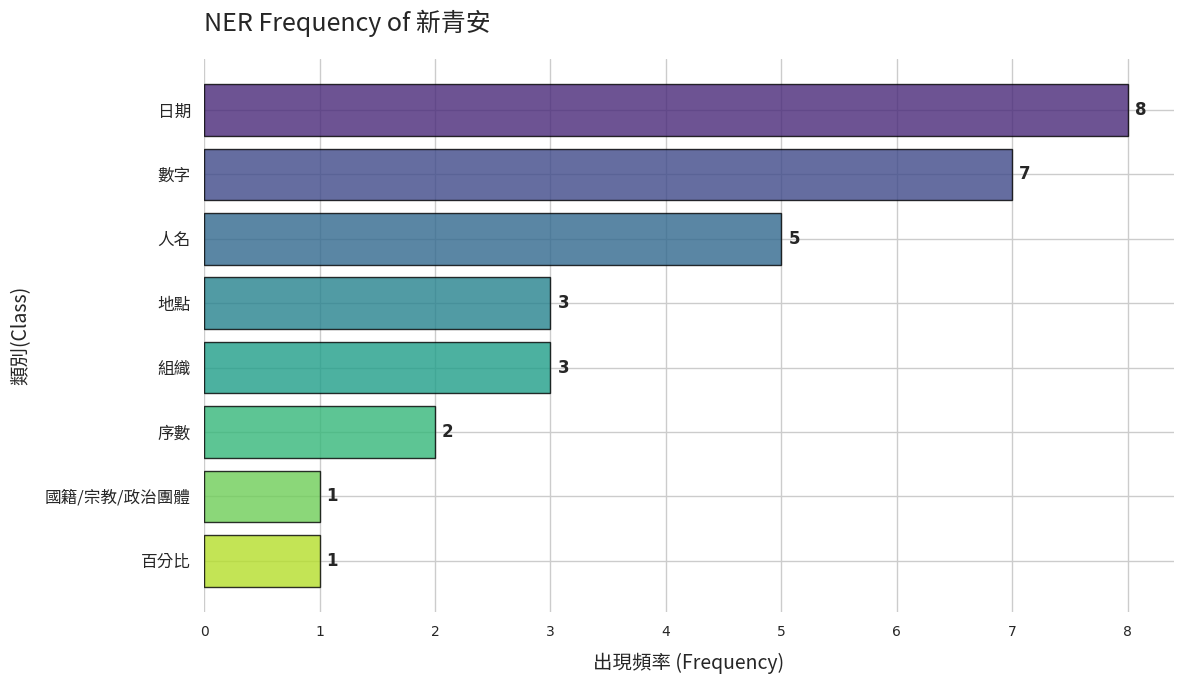

In [ ]:
ner = ner_count['ner_chinese']
count = ner_count['count']

plot_bar_chart(ner, count, title='NER Frequency of 新青安', color_palette='viridis')

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'left': 'Word Frequency (NER is ORG or PERSON)'}, xlabel='出現頻率 (Frequency)', ylabel='類別(Class)'>)

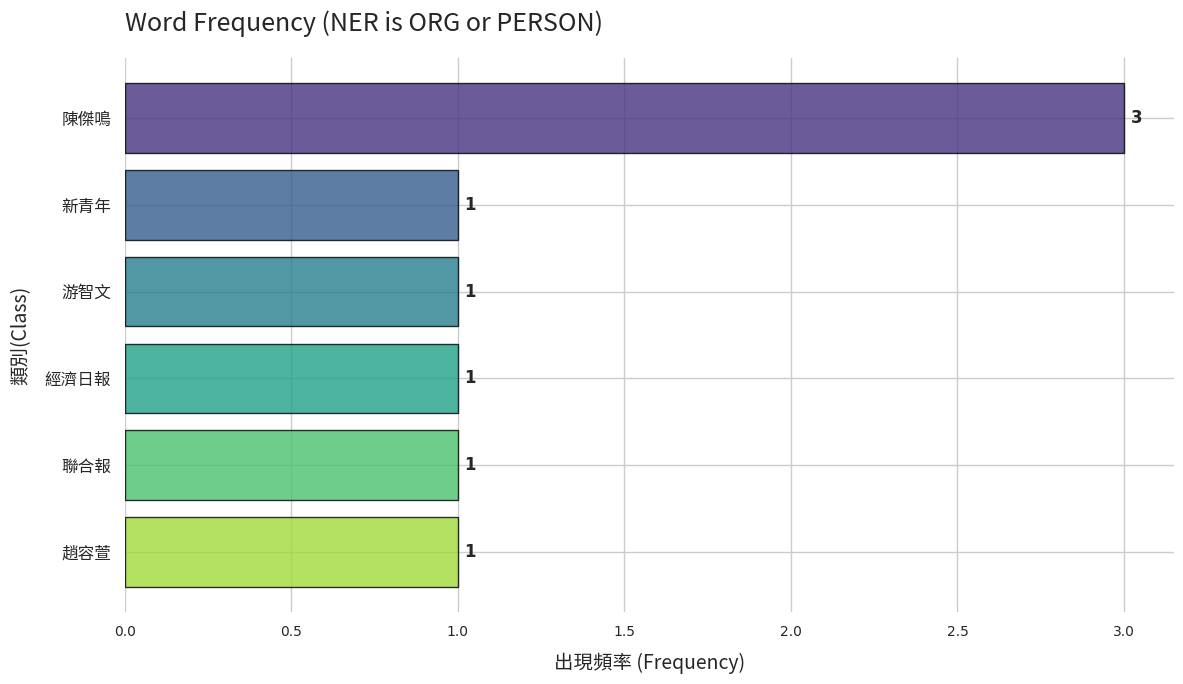

In [ ]:
# 文章內涉及的組織及人名
target_noun = ["ORG","PERSON"]
target = df_flat_ner[df_flat_ner.ner.isin(target_noun)]

# 計算每個名詞提到的次數，選出前10個
ner_count = target.groupby('word')['word'].agg(['count'])
ner_count = ner_count.sort_values(['count'],ascending=False)['count'].nlargest(20).reset_index()
ner_count

word = ner_count['word']
count = ner_count['count']

plot_bar_chart(word, count, title='Word Frequency (NER is ORG or PERSON)', color_palette='viridis')

## ▶️Sequence classification

### ▶️Sentiment Classification

In [ ]:
# 載入已經被 fine-tune 過的 BERT 模型
model_name = "techthiyanes/chinese_sentiment"  # 你可以將這裡換成你想要使用的模型
model = pipeline('sentiment-analysis', model=model_name)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: techthiyanes/chinese_sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
metaData_sampled = pd.concat([metaData.head(25), metaData.tail(25)]).reset_index(drop=True)

# 建立一個新的 dataframe 來儲存結果
results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])
results_df['sentence'] = metaData_sampled['sentence']

# 定義一個函數來進行情緒分析
def analyze_sentiment(sentence):
    result = model([sentence])
    return pd.Series([result[0]['label'], result[0]['score']])

# 使用 apply 函數來進行情緒分析
results_df[['label', 'score']] = metaData_sampled['sentence'].apply(analyze_sentiment)

# 輸出結果
results_df.head(10)

,sentence,label,score
0,內文經濟日報記者游智文即時報導,star 5,0.327415
1,新版青年安心成家優惠房貸專案今日上路,star 5,0.428825
2,元宏不動產加值服務平台研究總監陳傑鳴表示,star 5,0.503314
3,新青安房貸一降一拉一延的措施,star 3,0.282757
4,除了吸引首購進場,star 3,0.357665
5,對於部分面臨危機的建商而言,star 4,0.686431
6,也是救命浮木,star 5,0.578049
7,今天新上路的新青年安心成家購屋優惠貸款方案,star 4,0.423454
8,利息補助由原來補助半碼,star 5,0.252646
9,提高到碼,star 2,0.322934


/tmp/ipykernel_2834/3620034401.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_r")
/tmp/ipykernel_2834/3620034401.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fprop)


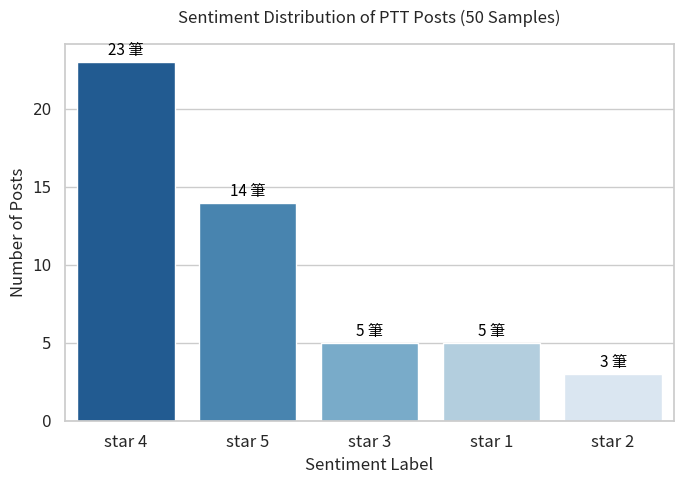

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 統計各個情緒標籤的數量
label_counts = results_df['label'].value_counts().sort_values(ascending=False)

# 2. 設定美觀的畫布風格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# 3. 繪製長條圖
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_r")

# 4. 設定圖表標題與座標軸名稱（全面調成 fprop）
plt.title('Sentiment Distribution of PTT Posts (50 Samples)', fontsize=14, pad=15, fontweight='bold', fontproperties=fprop)
plt.xlabel('Sentiment Label', fontsize=12, fontproperties=fprop)
plt.ylabel('Number of Posts', fontsize=12, fontproperties=fprop)

# 5. 在長條圖正上方標註「實際筆數」（這裡有中文字，強制加入 fontproperties=fprop 拆彈）
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} 筆',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline',
                fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points',
                fontproperties=fprop) # 👈 這裡最關鍵！

# 6. 確保 X 軸的刻度標籤也套用 fprop（預防萬一）
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fprop)

# 防止標籤被切到，完美收尾
plt.tight_layout()
plt.show()

模型採用1至5星進行評分，結果顯示輿論風向呈現顯著的「正面傾斜」。其中，正面情緒（4星與5星）高達37筆，總佔比達74%，反映出在抽樣文本中，多數鄉民對該房貸政策持肯定或高度期待。相較之下，中立（3星）與負面（1星與2星）情緒僅占極少數，分別為5筆與8筆。整體數據成功量化了當前的輿情態度，可作為後續深入探討政策正面滿意度的商務依據

### Relation Extraction (RE)

In [12]:
tokenizer = AutoTokenizer.from_pretrained("teppei727/bert-large-relation14")
model = AutoModelForSequenceClassification.from_pretrained("teppei727/bert-large-relation14")
re_model = pipeline("text-classification", model=model, tokenizer=tokenizer)

# 使用模型來進行 RE
text = [
    "My name is Wolfgang and I live in Berlin",
    "Obama was a USA president."
]
result = re_model(text)

result

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/369 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: teppei727/bert-large-relation14
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

[{'label': '[no connective]', 'score': 0.5112523436546326},
 {'label': 'Expansion.Conjunction', 'score': 0.6735802888870239}]

In [10]:
# 1. 先用 pip 下載並安裝中文模型套件
!pip install https://github.com/explosion/spacy-models/releases/download/zh_core_web_sm-3.7.0/zh_core_web_sm-3.7.0-py3-none-any.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 MB 10.1 MB/s eta 0:00:00


In [ ]:
import spacy

# 載入中文模型
nlp = spacy.load("zh_core_web_sm")

texts = pd.concat([metaData.head(25), metaData.tail(25)]).reset_index(drop=True)['sentence']

print("--- 語法樹深度剖析（多筆資料迴圈） ---\n")

for i, text in enumerate(texts, start=1):
    doc = nlp(text)

    # 【核心關鍵】每一筆文字都要重新初始化結果，才不會互相影響
    subjects = []
    objects = []
    relation = ""

    for token in doc:
        # 抓出句子裡的核心動詞
        if token.pos_ == "VERB" and token.dep_ == "ROOT":
            relation = token.text

            for t in doc:
                if t.head == token:
                    # 抓出發起動作的主詞（或主題）
                    if t.dep_ in ["nsubj", "top"]:
                        subjects.append("".join([w.text for w in t.subtree]))
                    # 抓出接受動作的受詞
                    elif t.dep_ in ["obj", "dobj"]:
                        objects.append("".join([w.text for w in t.subtree]))
            break # 抓到主根動詞後就跳出，避免後續複雜子句干擾

    print(f"第 {i} 筆文本：{text}")
    if relation:
        sub = subjects[0] if subjects else "【未抓到主詞】"
        obj = objects[0] if objects else "【未抓到受詞】"
        print(f"👉 真正抽取結果: ({sub}, {relation}, {obj})")
    else:
        print("👉 真正抽取結果: 【無法解析核心動詞關係】")
    print("-" * 50)

--- 語法樹深度剖析（多筆資料迴圈） ---

第 1 筆文本：內文經濟日報記者游智文即時報導
👉 真正抽取結果: (內文經濟日報記者游智文, 時報, 導)
--------------------------------------------------
第 2 筆文本：新版青年安心成家優惠房貸專案今日上路
👉 真正抽取結果: (新版青年, 成家, 優惠房貸專案)
--------------------------------------------------
第 3 筆文本：元宏不動產加值服務平台研究總監陳傑鳴表示
👉 真正抽取結果: (元宏, 加值, 服務平台)
--------------------------------------------------
第 4 筆文本：新青安房貸一降一拉一延的措施
👉 真正抽取結果: 【無法解析核心動詞關係】
--------------------------------------------------
第 5 筆文本：除了吸引首購進場
👉 真正抽取結果: (【未抓到主詞】, 吸引, 首購進場)
--------------------------------------------------
第 6 筆文本：對於部分面臨危機的建商而言
👉 真正抽取結果: 【無法解析核心動詞關係】
--------------------------------------------------
第 7 筆文本：也是救命浮木
👉 真正抽取結果: (【未抓到主詞】, 浮木, 【未抓到受詞】)
--------------------------------------------------
第 8 筆文本：今天新上路的新青年安心成家購屋優惠貸款方案
👉 真正抽取結果: 【無法解析核心動詞關係】
--------------------------------------------------
第 9 筆文本：利息補助由原來補助半碼
👉 真正抽取結果: (利息補助, 補助, 半碼)
--------------------------------------------------
第 10 筆文本：提高到碼
👉 真正抽取結果: (【未抓到主詞】, 提高, 碼)
--------------------------

In [ ]:
metaData_sampled = pd.concat([metaData.head(25), metaData.tail(25)]).reset_index(drop=True)

# 建立一個新的 dataframe 來儲存結果
re_results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])
re_results_df['sentence'] = metaData_sampled['sentence']

# 定義一個函數來進行 RE 任務
def get_re_result(sentence):
    result = re_model([sentence])
    return pd.Series([result[0]['label'], result[0]['score']])

# 使用 apply 函數來進行 RE 任務
re_results_df[['label', 'score']] = metaData_sampled['sentence'].apply(get_re_result)

re_results_df.head(10)

,sentence,label,score
0,內文經濟日報記者游智文即時報導,[no connective],0.411677
1,新版青年安心成家優惠房貸專案今日上路,[no connective],0.753884
2,元宏不動產加值服務平台研究總監陳傑鳴表示,[no connective],0.762362
3,新青安房貸一降一拉一延的措施,[no connective],0.771124
4,除了吸引首購進場,[no connective],0.808646
5,對於部分面臨危機的建商而言,[no connective],0.371343
6,也是救命浮木,[no connective],0.651878
7,今天新上路的新青年安心成家購屋優惠貸款方案,[no connective],0.549150
8,利息補助由原來補助半碼,[no connective],0.768775
9,提高到碼,[no connective],0.871944


## ▶️Text Clustering

### ▶️基本用法介紹

In [ ]:
!pip install bertopic

In [ ]:
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

# docs = en_origin_data['sentence'].tolist()
# docs = pd.concat([metaData.head(250), metaData.tail(250)]).reset_index(drop=True)['sentence'].tolist()
docs = metaData['sentence'].tolist()

# 定義不同 layer 所要使用的模型與方法
embedding_model = "all-MiniLM-L6-v2" # Embeddings layer
hdbscan_model = HDBSCAN() # Clustering layer
vectorizer_model = CountVectorizer()

topic_model = BERTopic(embedding_model=embedding_model, hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model)
topics, probs = topic_model.fit_transform(docs[:500])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,41,-1_一名貸款專員則現身說法_陳傑鳴表示_鉦德上午在臉書分享新青安貸款方案的內容_觀光人潮,"[一名貸款專員則現身說法, 陳傑鳴表示, 鉦德上午在臉書分享新青安貸款方案的內容, 觀光人潮...","[小坪數從早鳥價每坪萬元, 陳傑鳴表示, 市場上原本觀望]"
1,0,37,0_月減_單月衰退幅度為四都之最_六都公布今年月買賣移轉棟數_以及本月將進入民俗月,"[月減, 單月衰退幅度為四都之最, 六都公布今年月買賣移轉棟數, 以及本月將進入民俗月, 一...","[月減, 月減, 月減]"
2,1,30,1_不過仍有如新青安貸款等優惠政策釋出_主要考量新青安前三年太香_作者奶奶看板標題新聞新青安...,"[不過仍有如新青安貸款等優惠政策釋出, 主要考量新青安前三年太香, 作者奶奶看板標題新聞新青...","[政府於月日提出新青安房貸, 即使申請新青安取得最高貸款額度萬元, 新青安貸款威力開始了]"
3,2,30,2_也是房地合一上路後最冷的月_以及台北巿的內湖南港與總銷約億的信義區基隆路案_例如新北第一...,"[也是房地合一上路後最冷的月, 以及台北巿的內湖南港與總銷約億的信義區基隆路案, 例如新北第...","[台南前三名為東區永康區北區, 以及台北巿的內湖南港與總銷約億的信義區基隆路案, 也是房地合..."
4,3,26,3_不少人買來置產_不少小型建商面臨財務危機_到你成屋之前還有時間可以調整_估計超過億以上,"[不少人買來置產, 不少小型建商面臨財務危機, 到你成屋之前還有時間可以調整, 估計超過億以...","[或是貸款成數很低嗎, 該上車的要上車囉, 小弟是歲的上班族]"
5,4,24,4_寬限年_個人年薪大概是萬上下_今年下半年業者較沉潛_以減輕年輕朋友們在住房上的壓力與煩惱,"[寬限年, 個人年薪大概是萬上下, 今年下半年業者較沉潛, 以減輕年輕朋友們在住房上的壓力與...","[將更能減輕有購房意願年輕人的壓力, 寬限年, 寬限年]"
6,5,21,5_最高貸款額度從萬元提高至_包括提高貸款額度加碼利息補貼延長貸款期限及貸款寬限_一直不是很...,"[最高貸款額度從萬元提高至, 包括提高貸款額度加碼利息補貼延長貸款期限及貸款寬限, 一直不是...","[年減高雄棟, 最高貸款額度從萬元提高至, 最高貸款額度從萬元提高至]"
7,6,19,6_以我同溫層來說系上所上快個樣本公務員傳產新創系統廠金融業上山少部分發哥和二哥讀博在神山的...,[以我同溫層來說系上所上快個樣本公務員傳產新創系統廠金融業上山少部分發哥和二哥讀博在神山的大...,"[還有如果有預借現金也是會扣分, 跟我一樣的人很多甚至條件更好雙神山雙一線爸媽贊助我沒拿家裡..."
8,7,18,7_政府會一直站在年輕人這邊_更是政府無可迴避的責任_持續推動一系列保障居住權的政策_市場雖...,"[政府會一直站在年輕人這邊, 更是政府無可迴避的責任, 持續推動一系列保障居住權的政策, 市...","[政府會一直站在年輕人這邊, 政府會一直站在年輕人這邊, 政府會一直站在年輕人這邊]"
9,8,17,8_減輕大家買房的負擔_值得注意的是_有些較在意民俗的自住買家_某資深房市專家透露,"[減輕大家買房的負擔, 值得注意的是, 有些較在意民俗的自住買家, 某資深房市專家透露, 能...","[減輕大家買房的負擔, 減輕大家買房的負擔, 減輕大家買房的負擔]"


In [ ]:
# 列出Topic 6的關鍵字和其對應的c TF-IDF分數
topic_model.get_topic(6)

[('以我同溫層來說系上所上快個樣本公務員傳產新創系統廠金融業上山少部分發哥和二哥讀博在神山的大概人', 0.14911649179243242),
 ('以上大概是同學狀況不慘吧反正人各有志同學會看大家混得很開心', 0.14911649179243242),
 ('不可能現在美國降到趴多已經走到升息循環最尾聲台灣還能撐在你就知道台灣經濟體質多強了你想看到台灣除非瘋狂升息到以上那絕對是超越金融海嘯等級的大風暴魯空該擔心的是到時飯碗你還在不在還有就是政府的新青安房貸已經告訴你答案了魯空真的以為銀行很想推年房貸嗎',
  0.14911649179243242),
 ('目前每個月還款金額大概是萬出頭利率出頭左右預售屋總價大概是逼近萬左右', 0.14911649179243242),
 ('現金約萬台幣另外一半身上資產約莫萬合計共約萬身上還有負債萬信貸加萬學貸', 0.14911649179243242),
 ('特別是最近陸續傳有小型建商資金不足的爛尾樓案', 0.14911649179243242),
 ('最後蛋白區畢業了在頭竹一次買了間預售付完簽約金開工款還有上下的現金商場有尚順走路有人行道基本機能也有就等服務業教育業餐飲業陸續進場成屋還三年等著讓他實現到竹科尖峰也是分鐘阿還有分流上班我是的',
  0.14911649179243242),
 ('最後其實神山同溫層空空還是不少不聽學長姐的勸告一直覺得會崩盤尤其在地人就有住竹東的同事看著家附近房價從萬崩到萬現在想退休換大房更買不下去阿更慘還不能退休',
  0.14911649179243242),
 ('回到自己這兩年公司狀況好反正網路上都有資訊第一年稅前第二年稅前剛領滿兩年存了左右把前一筆信貸還完信貸大概剩年初又信貸了出來回股市操作了一下最後現金有左右小賺一點剛好只買大盤然後信貸的錢到股市操作應該是必要的吧',
  0.14911649179243242),
 ('原文恕刪背景交代一下小弟正好年次前年台大非電資科系碩班畢業上山非產線常日班目前年資剛好兩年家住大安區老爸老媽公務員家裡一間年電梯大樓爸媽覺得房價隨時崩盤一天到晚都說別買房買了準備套死這樣的背景下我工作撐下去的動機卻是買房因為我知道快速累積資產打敗通膨早點退休做自己想做的事最簡單的方式',
  0.14911649179243242)]

In [ ]:
# 列出前10筆文章的BERTopic資訊
doc_topic_info = topic_model.get_document_info(docs[:500])
doc_topic_info.head(10)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,內文經濟日報記者游智文即時報導,20,20_蔡英文總統所帶領的執政團隊_藝文活動暢旺_記者游智文攝影_連結內文,"[蔡英文總統所帶領的執政團隊, 藝文活動暢旺, 記者游智文攝影, 連結內文, 誠品松菸進駐文...","[完整新聞內文, 內文經濟日報記者游智文即時報導, 記者游智文攝影]",蔡英文總統所帶領的執政團隊 - 藝文活動暢旺 - 記者游智文攝影 - 連結內文 - 誠品松菸...,1.000000,True
1,新版青年安心成家優惠房貸專案今日上路,17,17_青年安心成家房貸升級版今日正式上路_心得讓青年幫忙出貨去化庫存也不錯建商庫存清掉後又可...,"[青年安心成家房貸升級版今日正式上路, 心得讓青年幫忙出貨去化庫存也不錯建商庫存清掉後又可以...","[新版青年安心成家優惠房貸專案今日上路, 青年安心成家房貸升級版今日正式上路, 青年安心成家...",青年安心成家房貸升級版今日正式上路 - 心得讓青年幫忙出貨去化庫存也不錯建商庫存清掉後又可以...,1.000000,True
2,元宏不動產加值服務平台研究總監陳傑鳴表示,23,23_台灣房屋集團趨勢中心執行長張旭嵐表示_我覺得太硬了你先確定只花塊過一天可以嗎過來人表示...,"[台灣房屋集團趨勢中心執行長張旭嵐表示, 我覺得太硬了你先確定只花塊過一天可以嗎過來人表示,...","[創意家行銷副總經理柯仲武表示, 示意圖, 董憲成表示]",台灣房屋集團趨勢中心執行長張旭嵐表示 - 我覺得太硬了你先確定只花塊過一天可以嗎過來人表示 ...,1.000000,False
3,新青安房貸一降一拉一延的措施,1,1_不過仍有如新青安貸款等優惠政策釋出_主要考量新青安前三年太香_作者奶奶看板標題新聞新青安...,"[不過仍有如新青安貸款等優惠政策釋出, 主要考量新青安前三年太香, 作者奶奶看板標題新聞新青...","[政府於月日提出新青安房貸, 即使申請新青安取得最高貸款額度萬元, 新青安貸款威力開始了]",不過仍有如新青安貸款等優惠政策釋出 - 主要考量新青安前三年太香 - 作者奶奶看板標題新聞新...,1.000000,False
4,除了吸引首購進場,22,22_市場供需才跟著調價_市場近期股市回穩_有需求面的消費者就會進場購屋_讓房屋市場能夠健全發展,"[市場供需才跟著調價, 市場近期股市回穩, 有需求面的消費者就會進場購屋, 讓房屋市場能夠健...","[巿場人士透露, 加上國父紀念館也有改建計畫, 除了吸引首購進場]",市場供需才跟著調價 - 市場近期股市回穩 - 有需求面的消費者就會進場購屋 - 讓房屋市場能...,1.000000,True
5,對於部分面臨危機的建商而言,21,21_對於部分面臨危機的建商而言_建案齊漲也沒看到其他外部因素_普遍看法房巿已接近底部_發現...,"[對於部分面臨危機的建商而言, 建案齊漲也沒看到其他外部因素, 普遍看法房巿已接近底部, 發...","[好房網記者徐沛琪綜合報導, 發現部分建案漲價, 部分說不行]",對於部分面臨危機的建商而言 - 建案齊漲也沒看到其他外部因素 - 普遍看法房巿已接近底部 -...,1.000000,False
6,也是救命浮木,21,21_對於部分面臨危機的建商而言_建案齊漲也沒看到其他外部因素_普遍看法房巿已接近底部_發現...,"[對於部分面臨危機的建商而言, 建案齊漲也沒看到其他外部因素, 普遍看法房巿已接近底部, 發...","[好房網記者徐沛琪綜合報導, 發現部分建案漲價, 部分說不行]",對於部分面臨危機的建商而言 - 建案齊漲也沒看到其他外部因素 - 普遍看法房巿已接近底部 -...,1.000000,False
7,今天新上路的新青年安心成家購屋優惠貸款方案,17,17_青年安心成家房貸升級版今日正式上路_心得讓青年幫忙出貨去化庫存也不錯建商庫存清掉後又可...,"[青年安心成家房貸升級版今日正式上路, 心得讓青年幫忙出貨去化庫存也不錯建商庫存清掉後又可以...","[新版青年安心成家優惠房貸專案今日上路, 青年安心成家房貸升級版今日正式上路, 青年安心成家...",青年安心成家房貸升級版今日正式上路 - 心得讓青年幫忙出貨去化庫存也不錯建商庫存清掉後又可以...,1.000000,False
8,利息補助由原來補助半碼,-1,-1_一名貸款專員則現身說法_陳傑鳴表示_鉦德上午在臉書分享新青安貸款方案的內容_觀光人潮,"[一名貸款專員則現身說法, 陳傑鳴表示, 鉦德上午在臉書分享新青安貸款方案的內容, 觀光人潮...","[小坪數從早鳥價每坪萬元, 陳傑鳴表示, 市場上原本觀望]",一名貸款專員則現身說法 - 陳傑鳴表示 - 鉦德上午在臉書分享新青安貸款方案的內容 - 觀光...,0.000000,False
9,提高到碼,5,5_最高貸款額度從萬元提高至_包括提高貸款額度加碼利息補貼延長貸款期限及貸款寬限_一直不是很...,"[最高貸款額度從萬元提高至, 包括提高貸款額度加碼利息補貼延長貸款期限及貸款寬限, 一直不是...","[年減高雄棟, 最高貸款額度從萬元提高至, 最高貸款額度從萬元提高至]",最高貸款額度從萬元提高至 - 包括提高貸款額度加碼利息補貼延長貸款期限及貸款寬限 - 一直不...,0.955568,False


In [ ]:
# 視覺化主題分布：圓圈大小是主題的大小，圓圈的距離是主題之間的相似度
topic_model.visualize_topics()

# topic_model.get_topic_info()

圓圈大小：代表該主題的「文章規模」，圓圈越大表示討論熱度與筆數越高。

相對距離：代表主題間的「語意相似度」。距離越近、甚至相互重疊（如圖中幾處高密度群落），表示鄉民在這些主題間使用的詞彙與脈絡高度相關；反之，分散在不同象限的獨立圓圈，則代表截然不同的獨立輿論面向。
本圖成功證實並量化了 PTT 輿論已結構化地收斂成數個關鍵陣營。

其中 Topic -1 是 BERTopic 自動配置的『雜訊/離群值桶』，用來存放無法被強行歸類到各大核心陣營的零碎留言。

1. 政策實施與利弊攻防（偏向政策面）
對應主題：Topic 17（青年安心成家升級版上路）、Topic 5（貸款額度提高與利息補貼）、Topic 1（前三年太香）。

主要聚焦在「新青安」的具體法規細節。在激烈討論額度提高、寬限期延長，以及討論這項優惠是不是「讓青年幫忙建商出貨、去化房市庫存」的雙面刃。

2. 市場供需與建商存亡（偏向經濟產業面）
對應主題：Topic 22（市場供需調價與股市回檔）、Topic 21（部分面臨危機建商的救命浮木）。

探討政策對整體房價與產業的衝擊。風向指出近期伴隨股市回檔與供需調整，這項政策實質上成為了某些瀕臨危機、積壓庫存之建築商的「救命浮木」，語意充滿強烈的財經與市場操作討論。

3. 專家點評與宏觀背景（偏向輿論/觀點面）
對應主題：Topic 23（台灣房屋集團執行長張旭嵐表示...）、Topic 20（蔡英文總統執政團隊背景）。

引述各大房仲高層、趨勢專家的專業數據點評，並將時間軸與執政團隊的宏觀背景進行連結。

### ▶️Clustering model

In [ ]:
from sklearn.cluster import KMeans

# 使用 KMeans 作為分群算法，需要指定分群個數
cluster_model = KMeans(n_clusters=10)

# 定義不同 layer 所要使用的模型與方法
embedding_model = "all-MiniLM-L6-v2"
vectorizer_model = CountVectorizer()

# 將 BERTopic 的 hdbscan_model 替換為其他模型（cluster_model）
kmeans_topic_model = BERTopic(embedding_model=embedding_model, hdbscan_model=cluster_model, vectorizer_model=vectorizer_model)
topics, probs = kmeans_topic_model.fit_transform(docs[:500])

kmeans_topic_model.get_topic_info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,0,103,0_減輕大家買房的負擔_最高貸款額度從萬元提高至_值得注意的是_本月高雄主要受交屋潮助攻表現亮眼,"[減輕大家買房的負擔, 最高貸款額度從萬元提高至, 值得注意的是, 本月高雄主要受交屋潮助攻...","[減輕大家買房的負擔, 減輕大家買房的負擔, 減輕大家買房的負擔]"
1,1,94,1_月減_萬元貸款年限由年延長至年_寬限期從年延長至年等另外_單月衰退幅度為四都之最,"[月減, 萬元貸款年限由年延長至年, 寬限期從年延長至年等另外, 單月衰退幅度為四都之最, ...","[月減, 月減, 月減]"
2,2,71,2_一般來說_市場供需才跟著調價_市場近期股市回穩_形成個案表現,"[一般來說, 市場供需才跟著調價, 市場近期股市回穩, 形成個案表現, 怕購買後會沒有裝潢款...","[目前市場以自住首購及換屋客群為主, 有需求面的消費者就會進場購屋, 到你成屋之前還有時間可..."
3,3,60,3_心得_不過因為案源釋出量少_月高雄買賣移轉棟數前三大行政區為三民楠梓鼓山_此外甲桂林在高...,"[心得, 不過因為案源釋出量少, 月高雄買賣移轉棟數前三大行政區為三民楠梓鼓山, 此外甲桂林...","[記者游智文攝影, 心得, 心得]"
4,4,51,4_台南月買賣移轉棟數五年來最冷_下半年房市繼續走冷北屯單價差不多到頂了海線起飛_觀察雙北市...,"[台南月買賣移轉棟數五年來最冷, 下半年房市繼續走冷北屯單價差不多到頂了海線起飛, 觀察雙北...","[完整新聞連結或短網址不可用等轉載媒體備註, 台南月買賣移轉棟數五年來最冷, 台南月買賣移轉..."
5,5,48,5_青年安心成家房貸升級版今日正式上路_不過仍有如新青安貸款等優惠政策釋出_青安貸款升級版今...,"[青年安心成家房貸升級版今日正式上路, 不過仍有如新青安貸款等優惠政策釋出, 青安貸款升級版...","[鉦德上午在臉書分享新青安貸款方案的內容, 青年安心成家房貸升級版今日正式上路, 青年安心成..."
6,6,21,6_政府會一直站在年輕人這邊_他持保守態度_且維持有增無減的狀態或保障型房貸_持續推動一系列...,"[政府會一直站在年輕人這邊, 他持保守態度, 且維持有增無減的狀態或保障型房貸, 持續推動一...","[政府會一直站在年輕人這邊, 政府會一直站在年輕人這邊, 政府會一直站在年輕人這邊]"
7,7,19,7_以我同溫層來說系上所上快個樣本公務員傳產新創系統廠金融業上山少部分發哥和二哥讀博在神山的...,[以我同溫層來說系上所上快個樣本公務員傳產新創系統廠金融業上山少部分發哥和二哥讀博在神山的大...,"[包括興辦社會住宅房地合一稅實價登錄住宅法修正億元擴大租金補貼平均地權條例, 來到鳥不生蛋的..."
8,8,17,8_幾乎腰斬_他並承諾_房市低迷_當作標題,"[幾乎腰斬, 他並承諾, 房市低迷, 當作標題, 隨買氣提升, 銷售困難, 先說結論, 房仲...","[他並承諾, 幾乎腰斬, 房市低迷]"
9,9,16,9_護理師自備萬想衝了_許多自由業者好奇_支持首購族買房_捷運站及市府就在旁,"[護理師自備萬想衝了, 許多自由業者好奇, 支持首購族買房, 捷運站及市府就在旁, 房貸利率...","[但客源就那麼多, 捷運站及市府就在旁, 如降低產品坪數]"


In [ ]:
topics[:10]

[3, 5, 3, 5, 2, 0, 0, 5, 3, 0]

結合 KMeans 演算法後，將語料強行收攏至「固定 10 個核心主題」的統計結果。與預設模型不同，KMeans 的特性是不會產生 -1 雜訊桶，所有文本皆被妥善分類。

前兩大主題 Topic 0（103筆）與 Topic 1（94筆）佔據近四成討論，核心聚焦於新青安政策細節，如提高額度、延長貸款年限與寬限期。此外，模型精準捕捉到區域市場動態，包括 Topic 3（高雄移轉棟數）與 Topic 4（台南房市五年最冷），並延伸至政府挺青年立場（Topic 6）與護理師等特定首購族群的心聲（Topic 9）。

### ▶️套用於中文

In [ ]:
# 中文文章
docs_zh = metaData['sentence'].tolist()[:500]

# 設定繁體中文詞庫
jieba.set_dictionary('./dict/dict.txt.big')

# 新增 stopwords
with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopwords = [line.strip() for line in f.readlines()]

# 設定中文 embedding model
bert_sentence_model = SentenceTransformer("google-bert/bert-base-chinese")

# 將中文文章轉換為 embedding
embeddings = bert_sentence_model.encode(docs_zh, show_progress_bar=True)

# 定義不同 clustering layer 所要使用的模型與方法（就用 default 的 HDBSCAN）
hdbscan_model = HDBSCAN()

# 定義一個適合中文的分詞函數
def tokenize_zh(text):
    words = jieba.lcut(text)
    return words

# 建立一個使用 jieba 分詞的 CountVectorizer
jieba_vectorizer = CountVectorizer(tokenizer=tokenize_zh, stop_words=stopwords, analyzer='word', token_pattern=u"(?u)\\b\\w+\\b")

# 使用 BERTopic 進行主題模型建立
zh_topic_model = BERTopic(embedding_model=bert_sentence_model, vectorizer_model=jieba_vectorizer, verbose=True, top_n_words=30)
topics, probs = zh_topic_model.fit_transform(docs_zh, embeddings)

zh_topic_model.get_topic_info()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

2026-05-16 22:14:33,831 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 22:14:35,057 - BERTopic - Dimensionality - Completed ✓
2026-05-16 22:14:35,058 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 22:14:35,079 - BERTopic - Cluster - Completed ✓
2026-05-16 22:14:35,083 - BERTopic - Representation - Fine-tuning topics using representation models.
Building prefix dict from /content/drive/MyDrive/Colab Notebooks/w11/dict/dict.txt.big ...
DEBUG:jieba:Building prefix dict from /content/drive/MyDrive/Colab Notebooks/w11/dict/dict.txt.big ...
Loading model from cache /tmp/jieba.u4a91bf46e0c2aedf154d5b363a6ad492.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.u4a91bf46e0c2aedf154d5b363a6ad492.cache
Loading model cost 1.440 seconds.
DEBUG:jieba:Loading model cost 1.440 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.
2026-05-16 22:14:36,590 - BERTopic - Representation -

,Topic,Count,Name,Representation,Representative_Docs
0,-1,168,-1_ _個案_減輕_買房,"[ , 個案, 減輕, 買房, 負擔, 政策, 明年, 萬, 預售, 上路, 房地產, 購屋...","[減輕大家買房的負擔, 心得讓青年幫忙出貨去化庫存也不錯建商庫存清掉後又可以拉高價繼續推案青..."
1,0,68,0_ _指出_月減_年增,"[ , 指出, 月減, 年增, 剩下, 陳, 寬限, 棟, 他並, 承諾, 傑鳴, 腰斬, ...","[陳衍亮指出, 董憲成指出, 陳傑鳴指出]"
2,1,47,1_買氣_ _建案_市場,"[買氣, , 建案, 市場, 建商, 表現, 推案, 下半年, 價格, 巿, 面臨, 一波...","[剛性買盤可望成為下半年房市最主要的買氣支柱, 新推案買氣都相當低落, 市場買氣因打炒房政策..."
3,2,44,2_總銷_億_甲_,"[總銷, 億, 甲, , 交屋, 三重, 桂林, 東區, 包括, 預售, 觀察, 區, 大...","[包括總銷億的台北巿林森北路自建案南港總銷億的首泰大喆, 在雙北推出信義區總銷億元大隱青后萬..."
4,3,37,3_銀行_萬_證明_財力,"[銀行, 萬, 證明, 財力, 信貸, 信用, , 貸款, 還款, 信用卡, 方式, 新青...","[說不定還有別的可以拿來當財力證明來貸款, 每月經常性收入約萬目前每月租屋萬信貸學貸萬, 欲..."
5,4,30,4_買_退休_新竹_上山,"[買, 退休, 新竹, 上山, 買房, 反正, 真的, 小孩, 工作, 神山, 吃, 蛋白,...",[剛來新竹交通塞爆有次寒流下雨我開車個小時才回到市區租屋處行人地獄沒人行道給你走看學生超可憐...
6,5,27,5_貸款_新青安_青安_安心,"[貸款, 新青安, 青安, 安心, 青年, 升級版, 成家, 上路, 政府, 房貸, 優惠,...","[政府推出青年安心成家購屋優惠貸款精進方案, 青年安心成家房貸升級版今日正式上路, 青年安心..."
7,6,25,6_房屋_集團_台灣_趨勢,"[房屋, 集團, 台灣, 趨勢, 中心, 完整, 內文, , 不動產, 房網, 資深, 媒...","[台灣房屋集團趨勢中心經理李家妮表示, 台灣房屋集團趨勢中心提供, 台灣房屋集團趨勢中心資深..."
8,7,19,7_貸款額度_延長_萬元_年限,"[貸款額度, 延長, 萬元, 年限, 利息, 寬限期, 提高, 寬限, 拉長, 補助, 半碼...","[萬元貸款年限由年延長至年, 萬元貸款年限由年延長至年, 包括提高貸款額度加碼利息補貼延長貸..."
9,8,13,8_買賣_移轉_棟數_台南,"[買賣, 移轉, 棟數, 台南, 五年, 冷, 棟, 量, 公布, 六, 合計, 高雄, 鼓...","[台南月買賣移轉棟數五年來最冷, 台南月買賣移轉棟數五年來最冷, 其中台南月買賣移轉棟數]"


In [ ]:
zh_topic_model.visualize_topics()

In [ ]:
# 估算每個文件對BERTopic每個主題的機率分布
topic_distr, _ = zh_topic_model.approximate_distribution(docs_zh)

100%|██████████| 1/1 [00:00<00:00,  7.61it/s]


In [ ]:
# 以第18個文件為例，列出這份文件對每個主題的機率分布
zh_topic_model.visualize_distribution(topic_distr[18])

In [ ]:
# 列出主題的代表詞和其對應的權重
zh_topic_model.get_topic(3)

[('銀行', 0.08269251960194285),
 ('萬', 0.0823019271422559),
 ('證明', 0.07568623686414541),
 ('財力', 0.07568623686414541),
 ('信貸', 0.07249588585253351),
 ('信用', 0.07174948668611407),
 (' ', 0.07066428220515646),
 ('貸款', 0.06098088884947642),
 ('還款', 0.06058528967100795),
 ('信用卡', 0.056764677648109066),
 ('方式', 0.05140854668825132),
 ('新青安貸', 0.04399349577074825),
 ('貸到', 0.04399349577074825),
 ('分數', 0.04399349577074825),
 ('評分', 0.04399349577074825),
 ('九月', 0.04399349577074825),
 ('金額', 0.04399349577074825),
 ('還清', 0.04399349577074825),
 ('名下', 0.0403901931140053),
 ('申請', 0.0403901931140053),
 ('繳清', 0.0403901931140053),
 ('算', 0.0403901931140053),
 ('狀況', 0.037843118432072706),
 ('每月', 0.037843118432072706),
 ('提供', 0.037843118432072706),
 ('成', 0.037843118432072706),
 ('負債', 0.037843118432072706),
 ('萬左右', 0.037843118432072706),
 ('房貸', 0.035881993810519576),
 ('影響', 0.03427236445883421)]

#### 查看特定文章的主題分佈

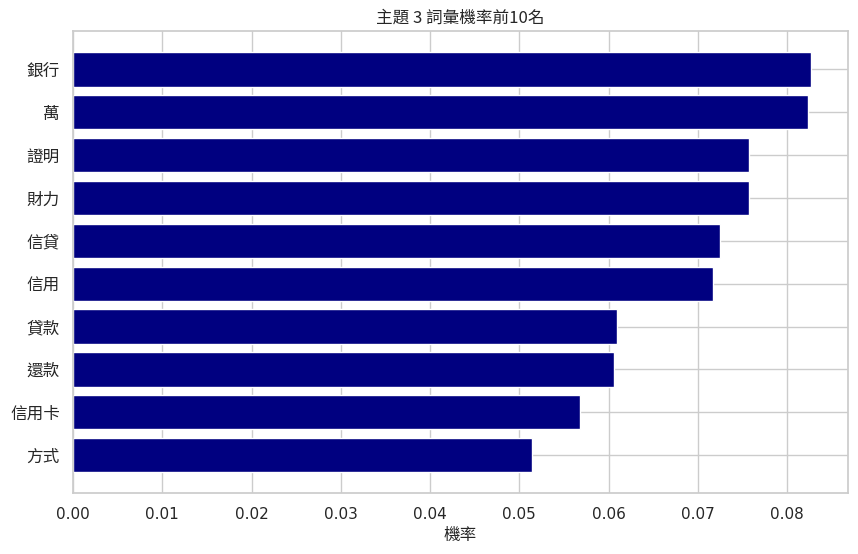

In [ ]:
# 視覺化顯示主題-詞彙分佈
topic_n = 3
data = zh_topic_model.get_topic(topic_n)

# 轉換為DataFrame
df = pd.DataFrame(data, columns=['word', 'prob'])
df = df[df['word'] != ' ']

# 根據prob排序並選出前10名
top_10 = df.sort_values('prob', ascending=False).head(10)

# 畫出長條圖
plt.figure(figsize=(10,6))
plt.barh(top_10['word'], top_10['prob'], color='navy')
plt.xlabel('機率', fontproperties=fprop)
plt.title(f'主題 {topic_n} 詞彙機率前10名', fontproperties=fprop)
plt.yticks(fontproperties=fprop)
plt.gca().invert_yaxis()
plt.show()

### ▶️用模型進行主題標籤的調整

In [ ]:
from bertopic.representation import KeyBERTInspired
# KeyBERT
keybert = KeyBERTInspired()

# 設定HDBscan模型
hdbscan_model = HDBSCAN(min_cluster_size=5, min_samples=30)

# 定義我們要用到的representation model（同學如果想比較其他模型可以在這邊加入其他模型方法）
representation_model = {
    "KeyBERT": keybert,
}

In [ ]:
# 建立BERTopic模型
representation_topic_model = BERTopic(
  # Sub-models
  embedding_model=bert_sentence_model,
  vectorizer_model=jieba_vectorizer,
  # 設定Representation model
  representation_model=representation_model,
  # Hyperparameters
  top_n_words=30,
  verbose=True
)

# Train model
topics, probs = representation_topic_model.fit_transform(docs_zh, embeddings)

2026-05-16 22:21:35,420 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 22:21:36,650 - BERTopic - Dimensionality - Completed ✓
2026-05-16 22:21:36,652 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 22:21:36,672 - BERTopic - Cluster - Completed ✓
2026-05-16 22:21:36,676 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 22:21:37,566 - BERTopic - Representation - Completed ✓


In [ ]:
# 觀察KeyBERT微調後的主題表示
representation_topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,Representative_Docs
0,-1,175,-1_ _減輕_負擔_買房,"[ , 減輕, 負擔, 買房, 政策, 預售, 個案, 明年, 庫存, 購屋, 想, 月減,...","[房地產, 年輕人, 減輕, 有助於, 關注, 首購族, 房貸, 網曝新北, 專家, 買房]","[減輕大家買房的負擔, 減輕大家買房的負擔, 減輕大家買房的負擔]"
1,0,49,0_買氣_ _建案_價格,"[買氣, , 建案, 價格, 建商, 市場, 表現, 推案, 下半年, 案, 巿, 面臨,...","[買賣雙方, 財務危機, 相當程度, 資金不足, 台北市, 消費者, 推案, 坪數, 建案,...","[預期明年房巿將有一波小陽春, 市場買氣因打炒房政策及保守氛圍而量縮, 新推案買氣都相當低落]"
2,1,44,1_ _剩下_棟_寬限,"[ , 剩下, 棟, 寬限, 腰斬, 不行, 年增, 心得, 合計, 小弟, 內文, 萬, ...","[減新北棟, 減高雄棟, 萬台幣, 中棟, 首購, 當作, 一般來說, 我貸, 年限, 剩下]","[剩下約萬, 只剩下萬可以運用, 年增台南棟]"
3,2,44,2_總銷_億_甲_,"[總銷, 億, 甲, , 交屋, 桂林, 三重, 東區, 包括, 觀察, 區, 預售, 大...","[林森北路, 環河北路, 自建案, 億漢寶, 新北市, 綻等案, 推案量, 心案, 推案, ...","[包括總銷億的台北巿林森北路自建案南港總銷億的首泰大喆, 在雙北推出信義區總銷億元大隱青后萬..."
4,3,32,3_萬_證明_財力_信貸,"[萬, 證明, 財力, 信貸, 信用, 還款, 貸款, , 信用卡, 銀行, 方式, 貸到...","[信用卡, 新青安貸, 當事人, 頭期款, 說不定, 房子, 信貸, 貸款, 房貸, 請問]","[說不定還有別的可以拿來當財力證明來貸款, 每月經常性收入約萬目前每月租屋萬信貸學貸萬, 欲..."
5,4,29,4_買_退休_新竹_做,"[買, 退休, 新竹, 做, 上山, 買房, 真的, 反正, 家裡, 工作, 學弟, 神山,...","[笑呵呵, 眼高手低, 第一個, 看著家, 難過, 公務員, 業但, 看房, 一票人, 機能]",[剛來新竹交通塞爆有次寒流下雨我開車個小時才回到市區租屋處行人地獄沒人行道給你走看學生超可憐...
6,5,29,5_貸款_新青安_安心_上路,"[貸款, 新青安, 安心, 上路, 青年, 成家, 青安, 升級版, 房貸, 政府, 方案,...","[優惠政策, 有增無減, 固定收入, 新青安三大, 升級版, 優貸, 保障型, 屋限貸, 措...","[今天新上路的新青年安心成家購屋優惠貸款方案, 青年安心成家房貸升級版今日正式上路, 青年安..."
7,6,24,6_房屋_集團_台灣_趨勢,"[房屋, 集團, 台灣, 趨勢, 中心, 完整, 內文, 資深, 新聞, 不動產, 房網, ...","[中國時報, 新聞標題, 經濟日報, 副總經理, 示意圖, 聯合報, 執行長, 房仲地, 宜...","[台灣房屋集團趨勢中心經理李家妮表示, 台灣房屋集團趨勢中心資深經理陳定中說, 台灣房屋集團..."
8,7,23,7_貸款額度_延長_年限_萬元,"[貸款額度, 延長, 年限, 萬元, 寬限期, 利息, 提高, 寬限, 拉長, 由年, 補助...","[貸款額度, 寬限期, 額度, 期限, 利息, 房貸, 貸款, 萬左右, 貸年, 由年]","[包括提高貸款額度加碼利息補貼延長貸款期限及貸款寬限, 萬元貸款年限由年延長至年, 萬元貸款..."
9,8,14,8_買賣_移轉_棟數_台南,"[買賣, 移轉, 棟數, 台南, 五年, 冷, 棟, 量, 公布, 六, 合計, 高雄, 房...","[棟數, 增六都, 移轉, 台南, 台中, 僅棟, 楠梓, 房市, 鼓山, 買賣]","[台南月買賣移轉棟數五年來最冷, 其中台南月買賣移轉棟數, 台南月買賣移轉棟數五年來最冷]"


傳統的 BERTopic 在找出主題後，是單純用「c-TF-IDF（類別詞頻-逆文件頻率）」去數數字，挑出在該主題出現頻率最高的字。
在主題出現次數多就選誰。

KeyBert 是後處理優化演算法，會將該主題中所有文章的 Bert 向量取平均，取得一個主題的中心座標。用 c-TF-IDF 抽取高頻字，最後用 Cosine Similarity 進行語意校正，去取得主題的核心語意特徵來決定選誰。

這張圖表是我們針對 11 萬筆數據進行「關鍵字精準度優化」後的明細結果。原本只靠電腦去數哪些字出現最多次，抓出來的關鍵字往往比較死板、零碎。

但在經過優化調整後，大家可以看到『KeyBERT』這一欄表現得非常漂亮。模型不再只是抓一些無意義的高頻單字，而是自動過濾出像『買賣雙方』、『財務危機』、『限貸令』、『首購族』這類真正有實質語意、有代表性的核心主題詞。這讓每一個主題的標籤名稱（Name）變得非常直觀，讓我們能用最快的速度、最精準地看懂 PTT 鄉民在各個討論陣營底下的真正心聲與核心論點。

透過模型分析 PTT 房產板及政黑板留言，經過結構化的收斂後，發現目前網路上針對新青安的討論，主要可以拆解成三大核心焦點：

【第一點：政策細節與還款壓力（實務面）】
「首先，最熱門的討論都在瘋『新青安』的實務條件。高度關注貸款額度提高、還款年限延長、以及寬限期的配套。但同時數據也顯示出大家的焦慮，很多人在詢問『財力證明怎麼開』、『信貸跟房貸會不會衝突』，反映出政策雖然誘人，但首購族對於未來的還款壓力其實非常精打細算。」

【第二點：建商拉貨與市場多空交戰（經濟面）】
「第二，數據精準抓到了市場的供需反應。有一部分的輿論在大聊建商的『總銷幾億』、建案『買氣』，認為這波政策成功刺激了房市；但妙的是，同時也出現了『銷售低迷』、『房市表現不佳』的討論。這代表市場目前處於強烈的多空交戰，有人覺得房市被炒熱，也有人認為高房價已經讓買氣出現疲態。」

【第三點：地方房市的溫度計（區域面）】
「最後，模型還幫我們抓到了有趣的區域特徵。像是『台南買賣移轉棟數』被鄉民點名面臨房市寒冬、討論度很高；而『新竹』則伴隨著退休、科技族群買房的剛性需求成為另一個討論焦點。

【結論】
總結來說，這 11 萬筆資料告訴我們，新青安政策確實全面引爆了網路上關於房貸細節、建商生態以及地方房市興衰的激辯，以上是我們的資料解讀。」